# VAD Tweets & Lyrics — Full Reanalysis Pipeline


## Setup

In [1]:
from pathlib import Path
import gc, hashlib, json, os, platform, re, time, unicodedata
import importlib.metadata
from collections import Counter
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import requests
import torch
from scipy.stats import gaussian_kde, mannwhitneyu, pearsonr, spearmanr
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (balanced_accuracy_score, mean_absolute_error,
                             mean_squared_error, r2_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
DATA = ROOT / 'data'
OUT = ROOT / 'analysis'
MODEL = ROOT / 'model'
for folder in [DATA, OUT, MODEL]:
    folder.mkdir(exist_ok=True)

torch.set_num_threads(4)
print('ROOT:', ROOT)


ROOT: /home/filipepimentel/Desktop/Thesis code/vad-tweets-lyrics


## Shared encoder configuration

Fixed encoder name/revision used everywhere embeddings are produced. Uses a
local Hugging Face cache when available (or `THESIS_ENCODER_PATH`), otherwise
downloads the pinned revision.


In [2]:
!pip install sentence-transformers

In [3]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
REVISION = '1110a243fdf4706b3f48f1d95db1a4f5529b4d41'

def load_encoder():
    override = os.environ.get('THESIS_ENCODER_PATH')
    cached = Path.home() / '.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2/snapshots' / REVISION

    if override or cached.exists():
        return SentenceTransformer(override or str(cached), device='cpu', local_files_only=True)
    
    return SentenceTransformer(MODEL_NAME, revision=REVISION, device='cpu')


## 1. Source VAD model

### 1.1 Download and verify EmoBank 

Retrieves the unchanged public EmoBank corpus and checks its SHA-256 against
the evaluated release hash.


In [4]:
EMOBANK_URL = 'https://raw.githubusercontent.com/JULIELab/EmoBank/master/corpus/emobank.csv'
EMOBANK_SHA256 = '1ade4a4a453e880c0f39d0536d2b355e8a716e0cf88236c64cdb4d438cf9605b'

emobank_path = DATA / 'emobank.csv'

if not emobank_path.exists():
    response = requests.get(EMOBANK_URL, timeout=60)
    response.raise_for_status()
    emobank_path.write_bytes(response.content)

actual = hashlib.sha256(emobank_path.read_bytes()).hexdigest()

if actual != EMOBANK_SHA256:
    raise ValueError('Corpus hash differs from evaluated release; inspect before reusing results')

print('EmoBank verified:', actual)


EmoBank verified: 1ade4a4a453e880c0f39d0536d2b355e8a716e0cf88236c64cdb4d438cf9605b


### 1.2 Train the VAD ridge predictor

Human-rated EmoBank → fixed MiniLM embeddings → ridge VAD predictor.
Regularisation is selected on the official development partition; the model
is then refit on train+dev and assessed once on the untouched official test
partition. Test predictions are **not** clipped.

**Step 1 — load and validate EmoBank.**


In [5]:
emobank_df = pd.read_csv(DATA / 'emobank.csv', dtype={'id': str, 'split': str}, keep_default_na=False)

valid_text = emobank_df['text'].map(lambda value: isinstance(value, str) and bool(value.strip()))

excluded_empty = int((~valid_text).sum())

emobank_df = emobank_df.loc[valid_text].reset_index(drop=True)

assert not emobank_df['id'].duplicated().any()
assert set(emobank_df['split']) == {'train', 'dev', 'test'}
assert emobank_df[['V', 'A', 'D']].notna().all().all()
assert emobank_df[['V', 'A', 'D']].ge(1).all().all() and emobank_df[['V', 'A', 'D']].le(5).all().all()

print('EmoBank rows:', len(emobank_df), '| excluded empty texts:', excluded_empty)


EmoBank rows: 10062 | excluded empty texts: 0


**Step 2 — encode with MiniLM (or reuse a cached embedding file), and
re-normalise.**


In [6]:
emobank_embedding_file = DATA / 'emobank_minilm.npy'

if emobank_embedding_file.exists():
    X = np.load(emobank_embedding_file, allow_pickle=False)
else:
    encoder = load_encoder()
    encoder.max_seq_length = 256
    print('Encoding EmoBank:', len(emobank_df), 'sentences', flush=True)
    t = time.monotonic()
    X = encoder.encode([str(value) for value in emobank_df['text']], batch_size=64,
                       show_progress_bar=True, convert_to_numpy=True,
                       normalize_embeddings=True)
    np.save(emobank_embedding_file, X)
    print('Embedding elapsed seconds:', round(time.monotonic() - t, 1), flush=True)

assert X.shape == (len(emobank_df), 384) and np.isfinite(X).all()

X = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
y = emobank_df[['V', 'A', 'D']].to_numpy(dtype=np.float64)

train_mask = emobank_df['split'].eq('train').to_numpy()
dev_mask = emobank_df['split'].eq('dev').to_numpy()
test_mask = emobank_df['split'].eq('test').to_numpy()

print('Splits:', {k: int(v.sum()) for k, v in [('train', train_mask), ('dev', dev_mask), ('test', test_mask)]})


Splits: {'train': 8062, 'dev': 1000, 'test': 1000}


**Step 3 — select ridge regularisation (alpha) per dimension on the dev
partition.**


In [7]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

dev_results = []

for alpha in alphas:
    predictor = Ridge(alpha=alpha).fit(X[train_mask], y[train_mask])
    pred = predictor.predict(X[dev_mask])
    
    for j, dim in enumerate(['V', 'A', 'D']):
        dev_results.append({'dimension': dim, 'alpha': alpha,
                            'rmse': float(np.sqrt(mean_squared_error(y[dev_mask, j], pred[:, j])))})

dev_df = pd.DataFrame(dev_results)
dev_df.to_csv(MODEL / 'development_selection.csv', index=False)
selected_alpha = {dim: float(dev_df.loc[dev_df['dimension'].eq(dim)].sort_values('rmse').iloc[0]['alpha'])
                  for dim in ['V', 'A', 'D']}

print('Selected alpha:', selected_alpha)


Selected alpha: {'V': 1.0, 'A': 1.0, 'D': 10.0}


**Step 4 — refit on train+dev with the selected alphas, evaluate once on the
untouched test partition (no clipping), and save the frozen ridge
coefficients.**


In [8]:
fit_mask = train_mask | dev_mask

coefs, intercepts, preds = [], [], []

for j, dim in enumerate(['V', 'A', 'D']):
    predictor = Ridge(alpha=selected_alpha[dim]).fit(X[fit_mask], y[fit_mask, j])
    coefs.append(predictor.coef_)
    intercepts.append(predictor.intercept_)
    preds.append(predictor.predict(X[test_mask]))

pred = np.column_stack(preds)
baseline = np.broadcast_to(y[fit_mask].mean(axis=0), pred.shape)

rows = []

for name, values in [('ridge', pred), ('training_mean', baseline)]:
    
    for j, dim in enumerate(['V', 'A', 'D']):
        rows.append({'model': name, 'dimension': dim, 'test_n': int(test_mask.sum()),
                     'mae': float(mean_absolute_error(y[test_mask, j], values[:, j])),
                     'rmse': float(np.sqrt(mean_squared_error(y[test_mask, j], values[:, j]))),
                     'r2': float(r2_score(y[test_mask, j], values[:, j])),
                     'pearson_r': float(pearsonr(y[test_mask, j], values[:, j]).statistic) if name == 'ridge' else None,
                     'spearman_rho': float(spearmanr(y[test_mask, j], values[:, j]).statistic) if name == 'ridge' else None})

metrics = pd.DataFrame(rows)

metrics.to_csv(MODEL / 'test_metrics.csv', index=False)

np.savez(MODEL / 'vad_ridge.npz', coef=np.asarray(coefs), intercept=np.asarray(intercepts),
         dimensions=np.array(['valence', 'arousal', 'dominance']),
         alpha=np.array([selected_alpha[d] for d in ['V', 'A', 'D']]))

test_output = emobank_df.loc[test_mask, ['id', 'V', 'A', 'D']].copy()

for j, dim in enumerate(['V', 'A', 'D']):
    test_output[f'pred_{dim}'] = pred[:, j]

test_output.to_csv(MODEL / 'heldout_predictions.csv', index=False)
print(metrics.to_string(index=False))


        model dimension  test_n      mae     rmse        r2  pearson_r  spearman_rho
        ridge         V    1000 0.205116 0.271367  0.381916   0.620098      0.606204
        ridge         A    1000 0.175353 0.222648  0.179636   0.435012      0.346843
        ridge         D    1000 0.146956 0.196663  0.125324   0.354699      0.318427
training_mean         V    1000 0.245469 0.345174 -0.000020        NaN           NaN
training_mean         A    1000 0.190267 0.245973 -0.001256        NaN           NaN
training_mean         D    1000 0.156353 0.210290 -0.000087        NaN           NaN


**Step 5 — write the evaluation manifest** (encoder revision, corpus hash,
split counts, selected alphas, software versions).


In [9]:
manifest = {
    'encoder': 'sentence-transformers/all-MiniLM-L6-v2', 'revision': REVISION,
    'max_seq_length': 256, 'normalize_embeddings': True,
    'gold_source': 'https://github.com/JULIELab/EmoBank',
    'corpus_sha256': hashlib.sha256((DATA / 'emobank.csv').read_bytes()).hexdigest(),
    'split_counts': emobank_df['split'].value_counts().to_dict(), 'excluded_empty_texts': excluded_empty,
    'selected_alpha': selected_alpha,
    'label_scale': [1, 5], 'prediction_clipping': False,
    'evaluation_scope': 'Official EmoBank test sentences; Twitter and lyric transfer unvalidated',
    'python': platform.python_version(),
    'packages': {p: importlib.metadata.version(p) for p in
                 ['numpy', 'pandas', 'scipy', 'scikit-learn', 'torch', 'transformers', 'sentence-transformers']},
}

(MODEL / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print('Selected alpha:', selected_alpha)


Selected alpha: {'V': 1.0, 'A': 1.0, 'D': 10.0}


### 1.3 Source-model uncertainty 

Paired sentence bootstrap of the frozen official EmoBank test predictions:
MAE, RMSE, Pearson r, and the RMSE gain over the training-mean baseline.


In [10]:
heldout_df = pd.read_csv(MODEL / 'heldout_predictions.csv')
fit_corpus = emobank_df[emobank_df.split.ne('test')]

rng = np.random.default_rng(20261006)
interval_rows = []

for d in ['V', 'A', 'D']:
    y_true = heldout_df[d].to_numpy()
    y_pred = heldout_df[f'pred_{d}'].to_numpy()
    mean_baseline = fit_corpus[d].mean()
    mae_samples, rmse_samples, r_samples, gain_samples = [], [], [], []
    
    for b in range(2000):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, pt = y_true[idx], y_pred[idx]
        mae_samples.append(np.abs(yt - pt).mean())
        rmse_samples.append(np.sqrt(((yt - pt) ** 2).mean()))
        r_samples.append(pearsonr(yt, pt).statistic)
        gain_samples.append(np.sqrt(((yt - mean_baseline) ** 2).mean()) - rmse_samples[-1])
    row = {'dimension': d}
    
    for label, values in [('mae', mae_samples), ('rmse', rmse_samples),
                          ('pearson_r', r_samples), ('baseline_minus_model_rmse', gain_samples)]:
        row[label + '_ci_low'], row[label + '_ci_high'] = np.quantile(values, [.025, .975])
    
    row['rmse_relative_reduction'] = 1 - np.sqrt(((y_true - y_pred) ** 2).mean()) / np.sqrt(((y_true - mean_baseline) ** 2).mean())
    interval_rows.append(row)

bootstrap_intervals = pd.DataFrame(interval_rows)
bootstrap_intervals.to_csv(MODEL / 'test_bootstrap_intervals.csv', index=False)
print(bootstrap_intervals.to_string(index=False))


dimension  mae_ci_low  mae_ci_high  rmse_ci_low  rmse_ci_high  pearson_r_ci_low  pearson_r_ci_high  baseline_minus_model_rmse_ci_low  baseline_minus_model_rmse_ci_high  rmse_relative_reduction
        V    0.194757     0.215700     0.256794      0.286876          0.578300           0.660267                          0.059945                           0.088682                 0.213824
        A    0.166759     0.183879     0.211959      0.232732          0.367393           0.500125                          0.013618                           0.033656                 0.094829
        D    0.139313     0.155286     0.184562      0.209713          0.289773           0.414251                          0.008473                           0.018568                 0.064800


## 2. Apply the frozen model 

Standalone utility that applies the saved ridge coefficients to any
N × 384 MiniLM embedding array. It L2-normalises each row, predicts in
batches of 50,000, and never clips. Rewritten here as a function
(`predict_vad`) plus a tiny demonstration using a random example batch
(reusing the already-computed EmoBank embeddings) so the logic can be
inspected without touching the original script's file-based CLI.


In [11]:
def predict_vad(embeddings, coef, intercept, batch_size=50000):
    """N x 384 MiniLM embeddings -> N x 3 (V, A, D), nominal 1-5 scale, no clipping."""

    if embeddings.ndim != 2 or embeddings.shape[1] != 384:
        raise ValueError('Expected N x 384 embeddings from all-MiniLM-L6-v2')
    
    result = np.empty((len(embeddings), 3), dtype=np.float32)
    
    for i in range(0, len(embeddings), batch_size):
        batch = np.asarray(embeddings[i:i + batch_size], dtype=np.float32)
        
        if not np.isfinite(batch).all():
            raise ValueError('Non-finite embedding')
        
        norms = np.linalg.norm(batch, axis=1, keepdims=True)
        
        if (norms <= 0).any():
            raise ValueError('Zero-length embedding')
        
        result[i:i + len(batch)] = (batch / norms) @ coef.T + intercept
    
    return result

# Demonstration: apply the frozen model to the first few EmoBank embeddings.
demo_model = np.load(MODEL / 'vad_ridge.npz', allow_pickle=False)
demo_predictions = predict_vad(X[:5], demo_model['coef'], demo_model['intercept'])
print('Demo VAD predictions (V, A, D), no clipping:')
print(demo_predictions)


Demo VAD predictions (V, A, D), no clipping:
[[2.7102857 3.1883824 3.0509593]
 [3.0523236 2.9861267 3.0958633]
 [3.0751686 2.959481  3.095065 ]
 [3.2666605 2.927267  3.117189 ]
 [3.17089   3.0447311 3.1143703]]


## 3. Download data 

Downloads only the public music-group files needed for the reanalysis
(profiles, timelines, URLs, and the five released embedding chunks), with
byte-range resume, SHA-256 verification against a local manifest, and
retries with backoff.


In [12]:
TARGET_FILES = {
    'User-Profiles-Music-Group.csv': 1065309,
    'User-Timelines-Music-Group.csv': 1231084007,
    'User-URLs-Music-Group.csv': 33591599,
    'music_having_chunk_embeddings_0-1999999.npy': 3072000128,
    'music_having_chunk_embeddings_2000000-3999999.npy': 3072000128,
    'music_having_chunk_embeddings_4000000-5999999.npy': 3072000128,
    'music_having_chunk_embeddings_6000000-7999999.npy': 3072000128,
    'music_having_chunk_embeddings_8000000-8976627.npy': 1500100736,
}

def sha256_of(path):
    digest = hashlib.sha256()
    
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b''):
            digest.update(block)
    
    return digest.hexdigest()

def download_target_data():
    manifest_path = DATA / 'download_manifest.json'
    manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
    
    for name, expected in TARGET_FILES.items():
        dest = DATA / name
        known_hash = manifest.get(name, {}).get('sha256')
        
        if dest.exists() and dest.stat().st_size == expected:
            actual_hash = sha256_of(dest)
            
            if known_hash and actual_hash != known_hash:
                raise ValueError(f'Existing {name} differs from the evaluated SHA-256')
            
            print('Already present:', name, flush=True)
            continue
        
        part = dest.with_suffix(dest.suffix + '.part')
        url = 'https://www.kaggle.com/api/v1/datasets/download/rrmartin/twitter-musicpd-melody-of-minds/' + name
        
        for attempt in range(5):
            offset = part.stat().st_size if part.exists() else 0
            
            try:
                headers = {'Range': f'bytes={offset}-'} if offset else {}
                
                with requests.get(url, headers=headers, stream=True, timeout=(30, 120)) as response:
                    response.raise_for_status()
                    
                    if offset and response.status_code != 206:
                        offset = 0
                    
                    if offset and not response.headers.get('content-range', '').startswith(f'bytes {offset}-'):
                        raise ValueError('Unexpected range response')
                    
                    mode = 'ab' if offset else 'wb'
                    last_report = time.monotonic()
                    started = time.monotonic()
                    written = offset
                    print('Downloading:', name, 'from byte', offset, flush=True)
                    
                    with part.open(mode) as stream:
                        
                        for block in response.iter_content(4 * 1024 * 1024):
                            
                            if block:
                                stream.write(block)
                                written += len(block)
                            
                            if time.monotonic() - last_report > 20:
                                speed = (written - offset) / max(time.monotonic() - started, 1) / 1e6
                                print(name, f'{written / expected:.1%}', f'{speed:.1f} MB/s', flush=True)
                                last_report = time.monotonic()
                
                if part.stat().st_size != expected:
                    raise ValueError(f'Size mismatch for {name}: {part.stat().st_size} != {expected}')
                
                actual_hash = sha256_of(part)
                
                if known_hash and actual_hash != known_hash:
                    part.unlink()
                    raise ValueError(f'Downloaded {name} differs from the evaluated SHA-256')
                
                part.rename(dest)
                manifest[name] = {'bytes': expected, 'sha256': actual_hash, 'source': url}
                manifest_path.write_text(json.dumps(manifest, indent=2))
                print('Verified:', name, expected, 'bytes', flush=True)
                break
            except Exception as exc:
                print('Retry', attempt + 1, name, type(exc).__name__, str(exc), flush=True)
                if attempt == 4:
                    raise
                time.sleep(min(2 ** attempt, 15))

if all((DATA / name).exists() and (DATA / name).stat().st_size == size for name, size in TARGET_FILES.items()):
    print('All target files already present and correctly sized; skipping download.')
else:
    download_target_data()


All target files already present and correctly sized; skipping download.


## 4. Metadata audit 

Audits row identity, source labels, reference types, and the primary tweet
filters (excluding `tweet_type == diagnose/anchor` posts and retweets),
streaming the timeline CSV in 200,000-row chunks to build a global
participant-code / eligibility / primary-mask index aligned to the released
embedding row order.

**Step 1 — load eligible participant profiles.**


In [13]:
profiles = pd.read_csv(DATA / 'User-Profiles-Music-Group.csv', dtype=str, keep_default_na=False)

assert not profiles['anonymized_id'].duplicated().any()

profiles = profiles[profiles['disorder'].isin(['depression', 'control'])].copy()
profiles = profiles.sort_values('anonymized_id').reset_index(drop=True)
ids = pd.Index(profiles['anonymized_id'])
profiles[['anonymized_id', 'disorder']].rename(columns={'anonymized_id': 'participant_id'}).to_csv(
    OUT / 'participant_index.csv', index=False)

print('Eligible participants:', len(ids))


Eligible participants: 4652


**Step 2 — stream the full timeline CSV, asserting row-order alignment with
the released embeddings, and build the eligibility/primary masks plus
tweet-type/reference-type counters.**


In [14]:
all_codes = np.full(8976628, -1, dtype=np.int32)
eligible = np.zeros(8976628, dtype=bool)
primary = np.zeros(8976628, dtype=bool)
tweet_hashes = np.empty(8976628, dtype=np.uint64)
counts, types, refs = Counter(), Counter(), Counter()
offset = 0

for chunk in pd.read_csv(DATA / 'User-Timelines-Music-Group.csv', dtype=str, keep_default_na=False, chunksize=200000):
    
    end = offset + len(chunk)
    assert end <= len(all_codes)
    positions = chunk.iloc[:, 0].astype(np.int64).to_numpy()
    assert np.array_equal(positions, np.arange(offset, end)), 'CSV row index no longer agrees with embedding order'
    
    codes = ids.get_indexer(chunk['anonymized_author_id'])
    relevant = codes >= 0
    
    if relevant.any():
        expected = profiles.iloc[codes[relevant]]['disorder'].to_numpy()
        assert np.array_equal(expected, chunk.loc[relevant, 'disorder'].to_numpy()), 'Group label mismatch'
    
    # Actual release uses 'diagnose', whereas the paper describes anchor flags.
    anchor = chunk['tweet_type'].str.lower().isin(['diagnose', 'anchor']).to_numpy()
    retweet = chunk['referenced_tweet_type'].str.contains('retweeted', case=False, na=False).to_numpy()
    all_codes[offset:end] = codes
    eligible[offset:end] = relevant & ~anchor
    primary[offset:end] = relevant & ~anchor & ~retweet
    tweet_hashes[offset:end] = pd.util.hash_pandas_object(chunk['anonymized_id'], index=False).to_numpy()
    types.update(chunk['tweet_type'].value_counts().to_dict())
    refs.update(chunk['referenced_tweet_type'].value_counts().to_dict())
    counts['source_rows'] += len(chunk)
    counts['target_group_rows'] += int(relevant.sum())
    counts['target_anchor_rows'] += int((relevant & anchor).sum())
    counts['target_retweet_rows'] += int((relevant & ~anchor & retweet).sum())
    counts['primary_rows'] += int((relevant & ~anchor & ~retweet).sum())
    offset = end
    
    if offset % 1000000 == 0:
        print('Metadata audited:', offset, flush=True)

assert offset == len(all_codes)
unique_hashes = len(np.unique(tweet_hashes))
assert unique_hashes == offset, 'Duplicate tweet IDs need a documented deduplication decision'
print('Streaming complete. Unique tweet-id hashes:', unique_hashes)


Metadata audited: 1000000
Metadata audited: 2000000
Metadata audited: 3000000
Metadata audited: 4000000
Metadata audited: 5000000
Metadata audited: 6000000
Metadata audited: 7000000
Metadata audited: 8000000
Streaming complete. Unique tweet-id hashes: 8976628


**Step 3 — save the row index, per-participant tweet counts, and the audit
report.**


In [15]:
np.savez_compressed(OUT / 'tweet_row_index.npz', participant_code=all_codes, primary=primary, all_nonanchor=eligible)

primary_counts = np.bincount(all_codes[primary], minlength=len(ids))
all_counts = np.bincount(all_codes[eligible], minlength=len(ids))
profiles['primary_tweet_count'] = primary_counts
profiles['nonanchor_tweet_count'] = all_counts
profiles[['anonymized_id', 'disorder', 'primary_tweet_count', 'nonanchor_tweet_count']].rename(
    columns={'anonymized_id': 'participant_id'}).to_csv(OUT / 'tweet_counts.csv', index=False)

metadata_report = {
    'counts': dict(counts), 'tweet_types': dict(types), 'reference_types': dict(refs),
    'unique_tweet_id_hashes': unique_hashes,
    'participants': len(ids), 'participants_without_primary_tweets': int((primary_counts == 0).sum()),
    'primary_count_quantiles': np.quantile(primary_counts, [0, .25, .5, .75, 1]).tolist(),
    'selection': 'Depression/control profiles; exclude tweet_type=diagnose or anchor and referenced_tweet_type=retweeted from primary; retain retweets in sensitivity'}
(OUT / 'metadata_audit.json').write_text(json.dumps(metadata_report, indent=2))
print(json.dumps(metadata_report, indent=2), flush=True)


{
  "counts": {
    "source_rows": 8976628,
    "target_group_rows": 6947822,
    "target_anchor_rows": 879,
    "target_retweet_rows": 7191,
    "primary_rows": 6939752
  },
  "tweet_types": {
    "timeline": 8974448,
    "diagnose": 2180
  },
  "reference_types": {
    "replied_to": 4522724,
    "None": 3494045,
    "quoted": 951817,
    "retweeted": 8042
  },
  "unique_tweet_id_hashes": 8976628,
  "participants": 4652,
  "participants_without_primary_tweets": 0,
  "primary_count_quantiles": [
    1.0,
    589.0,
    1682.0,
    2266.0,
    3247.0
  ],
  "selection": "Depression/control profiles; exclude tweet_type=diagnose or anchor and referenced_tweet_type=retweeted from primary; retain retweets in sensitivity"
}


## 5. Tweet scoring 

Streams the released embeddings in official CSV order (waiting for each
chunk file to be present), L2-normalises, scores with the frozen ridge
model (no clipping), and accumulates per-participant sums for two masks:
`primary` (diagnosis posts and retweets excluded) and `retweets_included`
(diagnosis posts excluded only). Means are only taken after summing — never
averaged per chunk.


In [16]:
tweet_index = np.load(OUT / 'tweet_row_index.npz', allow_pickle=False)
tweet_codes = tweet_index['participant_code']
tweet_masks = {'primary': tweet_index['primary'], 'retweets_included': tweet_index['all_nonanchor']}
participant_index_df = pd.read_csv(OUT / 'participant_index.csv', dtype=str)
vad_model = np.load(MODEL / 'vad_ridge.npz', allow_pickle=False)
vad_coef = vad_model['coef']
vad_intercept = vad_model['intercept']
N = len(participant_index_df)

tweet_sums = {k: np.zeros((N, 3)) for k in tweet_masks}
tweet_counts = {k: np.zeros(N, dtype=np.int64) for k in tweet_masks}
embedding_files = [(0, 2000000), (2000000, 4000000), (4000000, 6000000), (6000000, 8000000), (8000000, 8976628)]
embedding_audit = {'chunks': [], 'normalization': 'L2-normalize each released tweet embedding before prediction',
                   'clipping': False,
                   'ordering': 'Preserve original global CSV row order; boundaries from official filenames'}

for begin, end in embedding_files:
    filename = f'music_having_chunk_embeddings_{begin}-{end - 1}.npy'
    path = DATA / filename
    print('Waiting for verified file:', filename, flush=True)
    
    while not path.exists():
        time.sleep(10)
    
    X_chunk = np.load(path, mmap_mode='r', allow_pickle=False)
    
    assert X_chunk.shape == (end - begin, 384), f'Unexpected embedding shape {X_chunk.shape}'
    norm_min, norm_max = float('inf'), 0.
    low, high = np.full(3, np.inf), np.full(3, -np.inf)
    outside = 0
    
    for local in range(0, len(X_chunk), 50000):
        stop = min(local + 50000, len(X_chunk))
        global_start, global_end = begin + local, begin + stop
        values = np.asarray(X_chunk[local:stop], dtype=np.float32)
        
        assert np.isfinite(values).all(), 'Non-finite embedding'
        norms = np.linalg.norm(values, axis=1)
        
        assert (norms > 0).all(), 'Zero-length embedding'
        norm_min, norm_max = min(norm_min, float(norms.min())), max(norm_max, float(norms.max()))
        pred = (values / norms[:, None]) @ vad_coef.T + vad_intercept
        relevant = tweet_codes[global_start:global_end] >= 0
        
        if relevant.any():
            low = np.minimum(low, pred[relevant].min(axis=0))
            high = np.maximum(high, pred[relevant].max(axis=0))
            outside += int(((pred[relevant] < 1) | (pred[relevant] > 5)).any(axis=1).sum())
        
        for key, mask in tweet_masks.items():
            selected = mask[global_start:global_end]
            np.add.at(tweet_sums[key], tweet_codes[global_start:global_end][selected], pred[selected])
            tweet_counts[key] += np.bincount(tweet_codes[global_start:global_end][selected], minlength=N)
    
    embedding_audit['chunks'].append({'file': filename, 'shape': list(X_chunk.shape), 'dtype': str(X_chunk.dtype),
                                      'norm_min': norm_min, 'norm_max': norm_max,
                                      'target_prediction_min': low.tolist(), 'target_prediction_max': high.tolist(),
                                      'target_predictions_outside_nominal_range': outside})
    
    np.savez(OUT / 'tweet_aggregation_checkpoint.npz',
             **{f'{k}_sum': v for k, v in tweet_sums.items()},
             **{f'{k}_n': v for k, v in tweet_counts.items()}, completed_through=end)
    (OUT / 'embedding_audit.json').write_text(json.dumps(embedding_audit, indent=2))
    
    print('Scored through global row:', end, flush=True)

for key in tweet_masks:
    assert (tweet_counts[key] > 0).all()
    result_df = participant_index_df.copy()
    result_df['tweet_count'] = tweet_counts[key]
    means = tweet_sums[key] / tweet_counts[key][:, None]
    
    for j, dim in enumerate(['V', 'A', 'D']):
        result_df[f'tweet_{dim}'] = means[:, j]
    
    result_df.to_csv(OUT / f'tweet_vad_{key}.csv', index=False)

print('Tweet scoring complete', flush=True)


Waiting for verified file: music_having_chunk_embeddings_0-1999999.npy
Scored through global row: 2000000
Waiting for verified file: music_having_chunk_embeddings_2000000-3999999.npy
Scored through global row: 4000000
Waiting for verified file: music_having_chunk_embeddings_4000000-5999999.npy
Scored through global row: 6000000
Waiting for verified file: music_having_chunk_embeddings_6000000-7999999.npy
Scored through global row: 8000000
Waiting for verified file: music_having_chunk_embeddings_8000000-8976627.npy
Scored through global row: 8976628
Tweet scoring complete


In [17]:
if 'THESIS_SONGS_CSV' not in os.environ:
    candidates = [DATA / 'User-Songs-Music-Group.xls', ROOT.parent / 'User-Songs-Music-Group.xls']
    found = next((c for c in candidates if c.exists()), None)

    if found is not None:
        os.environ['THESIS_SONGS_CSV'] = str(found)
        print('THESIS_SONGS_CSV not set; using discovered file:', found)
    else:
        raise FileNotFoundError(
            'User-Songs-Music-Group.xls not found. Set THESIS_SONGS_CSV to its absolute path '
            f'(checked: {[str(c) for c in candidates]})')

else:
    print('THESIS_SONGS_CSV already set:', os.environ['THESIS_SONGS_CSV'])

THESIS_SONGS_CSV not set; using discovered file: /home/filipepimentel/Desktop/Thesis code/User-Songs-Music-Group.xls


## 6. Music-post exclusion 

Subtracts known music-sharing posts (tweet IDs present in the original song
table, matched via `THESIS_SONGS_CSV`) from the primary per-participant tweet
sums, producing a sensitivity variant `tweet_vad_music_posts_excluded.csv`.


In [18]:
songs_csv_path = Path(os.environ.get('THESIS_SONGS_CSV', str(DATA / 'User-Songs-Music-Group.xls')))
music_df = pd.read_csv(songs_csv_path, usecols=['anonymized_tweet_id'], dtype=str, keep_default_na=False)
music_ids = set(music_df.anonymized_tweet_id)

music_index = np.load(OUT / 'tweet_row_index.npz')
music_primary_mask = music_index['primary']
music_codes = music_index['participant_code']
selected = np.zeros(len(music_primary_mask), dtype=bool)
start = 0

for chunk in pd.read_csv(DATA / 'User-Timelines-Music-Group.csv', usecols=['anonymized_id'], dtype=str,
                         keep_default_na=False, chunksize=200000):
    end = start + len(chunk)
    selected[start:end] = chunk.anonymized_id.isin(music_ids).to_numpy() & music_primary_mask[start:end]
    start = end

assert start == len(music_primary_mask)

participants_for_exclusion = pd.read_csv(OUT / 'participant_index.csv', dtype=str)
N_music = len(participants_for_exclusion)
music_model = np.load(MODEL / 'vad_ridge.npz')
removed_sum = np.zeros((N_music, 3))
removed_count = np.zeros(N_music, dtype=np.int64)

for begin, end in [(0, 2000000), (2000000, 4000000), (4000000, 6000000), (6000000, 8000000), (8000000, 8976628)]:
    X_chunk = np.load(DATA / f'music_having_chunk_embeddings_{begin}-{end - 1}.npy', mmap_mode='r')
    mask = selected[begin:end]
    local_codes = music_codes[begin:end][mask]
    values = np.asarray(X_chunk[mask], dtype=np.float32)
    values /= np.linalg.norm(values, axis=1, keepdims=True)
    pred = values @ music_model['coef'].T + music_model['intercept']
    np.add.at(removed_sum, local_codes, pred)
    removed_count += np.bincount(local_codes, minlength=N_music)

checkpoint = np.load(OUT / 'tweet_aggregation_checkpoint.npz')
assert checkpoint['completed_through'] == 8976628

counts_after = checkpoint['primary_n'] - removed_count
sums_after = checkpoint['primary_sum'] - removed_sum
keep = counts_after > 0
music_excluded_result = participants_for_exclusion.loc[keep].copy()
music_excluded_result['tweet_count'] = counts_after[keep]

for j, d in enumerate(['V', 'A', 'D']):
    music_excluded_result[f'tweet_{d}'] = sums_after[keep, j] / counts_after[keep]

music_excluded_result.to_csv(OUT / 'tweet_vad_music_posts_excluded.csv', index=False)

music_exclusion_audit = {
    'known_music_tweet_ids': len(music_ids), 'excluded_primary_music_posts': int(removed_count.sum()),
    'retained_tweets': int(counts_after.sum()), 'participants_without_nonmusic_primary_posts': int((~keep).sum()),
    'retained_participants': int(keep.sum()),
    'scope': 'Remove tweet IDs appearing in original song table, including entries later rejected for lyric quality; other music-related tweets cannot be identified without text'}
(OUT / 'music_post_exclusion_audit.json').write_text(json.dumps(music_exclusion_audit, indent=2))

print(json.dumps(music_exclusion_audit, indent=2))


{
  "known_music_tweet_ids": 78257,
  "excluded_primary_music_posts": 25202,
  "retained_tweets": 6914550,
  "participants_without_nonmusic_primary_posts": 2,
  "retained_participants": 4650,
  "scope": "Remove tweet IDs appearing in original song table, including entries later rejected for lyric quality; other music-related tweets cannot be identified without text"
}


## 7. Lyric scoring 

Scores cleaned full lyrics using nonoverlapping MiniLM token chunks (254
content wordpieces each, framed with CLS/SEP, so each sequence stays within
the 256-token limit). Every chunk uses the same tokenizer, pooling and
normalization as the EmoBank encoder. Song-level scores are a chunk length
weighted mean. Nothing is clipped. Raw lyric text stays only in the local
`lyric_cache/` working directory.

**Step 1 — text cleaning and title-match helpers.**


In [19]:
LYRIC_CACHE = ROOT / 'lyric_cache'
LYRIC_CACHE.mkdir(exist_ok=True)

lyric_encoder = load_encoder()
lyric_encoder.eval()
lyric_encoder.max_seq_length = 256
lyric_tokenizer = lyric_encoder.tokenizer
lyric_predictor = np.load(MODEL / 'vad_ridge.npz', allow_pickle=False)
lyric_coef = lyric_predictor['coef']
lyric_intercept = lyric_predictor['intercept']

def clean(text):
    text = str(text).strip()
    marker = re.search(r'\bLyrics', text[:300])
    
    if marker:
        text = text[marker.end():]
    text = re.sub(r'\d*Embed\s*$', '', text)
    text = re.sub(r'\[(?:verse|chorus|pre[- ]?chorus|post[- ]?chorus|bridge|intro|outro|hook|refrain|instrumental|interlude|solo|break|spoken|part)(?:[^\]]*)\]', ' ', text, flags=re.I)
    
    return re.sub(r'\s+', ' ', text).strip()

def canonical(text, strip_suffix=True):
    text = str(text)
    
    if strip_suffix:
        text = re.split(r'\s+-\s+', text)[0]
    
    text = re.sub(r'\([^)]*(?:feat|remaster|version|remix|edit|live|bonus)[^)]*\)', '', text, flags=re.I)
    text = unicodedata.normalize('NFKD', text.lower())
    return ' '.join(''.join(c if c.isalnum() else ' ' for c in text if not unicodedata.combining(c)).split())

def title_check(title, artist, text):
    marker = re.search(r'\bLyrics', text[:300])
    
    if not marker:
        return '', False, 'missing_header'
    
    header = text[:marker.start()].strip()
    a, b = canonical(title), canonical(header, False)
    
    if re.search(r'discography|release calendar|new music friday|rapcaviar|highest to lowest|tracklist', b) or b == 'this is ' + canonical(artist):
        return header, False, 'catalogue_header'
    
    contains = (len(a) >= 4 and (' ' + a + ' ') in (' ' + b + ' ')) or (len(b) >= 4 and (' ' + b + ' ') in (' ' + a + ' '))
    ok = bool(a and b and (a == b or contains or SequenceMatcher(None, a, b).ratio() >= .80))
    
    return header, ok, 'matched' if ok else 'title_mismatch'


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /home/filipepimentel/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2/snapshots/1110a243fdf4706b3f48f1d95db1a4f5529b4d41
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Step 2 — build the quality-filtered song table** (deduplicate
participant/artist/title rows, run title-match checks, clean lyrics,
exclude empty or mismatched titles, cap at 8000 content wordpieces), and
cache the unique cleaned texts. Skipped if the cache already exists, so a
resumed run reuses prior work.


In [20]:
if not all(path.exists() for path in [OUT / 'participant_song_map.csv', LYRIC_CACHE / 'texts.jsonl']):
    songs_df = pd.read_csv(songs_csv_path, usecols=['anonymized_author_id', 'disorder', 'artist', 'title', 'lyric'],
                           dtype=str, keep_default_na=False)
    
    source_rows = len(songs_df)
    songs_df = songs_df[songs_df.disorder.isin(['depression', 'control'])].copy()
    target_rows = len(songs_df)
    
    for col in ['artist', 'title']:
        songs_df[col] = songs_df[col].str.strip()
    
    songs_df = songs_df.drop_duplicates(['anonymized_author_id', 'artist', 'title'], keep='first').reset_index(drop=True)
    retained = len(songs_df)

    checks = [title_check(t, a, l) for t, a, l in zip(songs_df.title, songs_df.artist, songs_df.lyric)]
    songs_df[['retrieved_header', 'title_match', 'title_status']] = pd.DataFrame(checks, index=songs_df.index)
    songs_df['cleaned'] = songs_df.lyric.map(clean)
    songs_df['lyric_id'] = songs_df.cleaned.map(lambda t: hashlib.sha256(t.encode()).hexdigest())
    
    nonempty = songs_df.cleaned.str.len().gt(0)
    exclusions = int((~nonempty).sum())
    title_status_counts = songs_df.title_status.value_counts().to_dict()
    
    songs_df[['anonymized_author_id', 'artist', 'title', 'retrieved_header', 'title_match', 'title_status', 'lyric_id']].to_csv(
        OUT / 'lyric_quality_audit.csv', index=False)

    songs_df = songs_df[nonempty & songs_df.title_match].copy()
    unique_songs = songs_df.drop_duplicates('lyric_id').reset_index(drop=True)
    token_counts = []

    for start in range(0, len(unique_songs), 500):
        tokenized = lyric_tokenizer(unique_songs.cleaned.iloc[start:start + 500].tolist(), add_special_tokens=False,
                                    truncation=False, verbose=False)['input_ids']
        token_counts.extend(map(len, tokenized))

    unique_songs['token_count'] = token_counts
    songs_df = songs_df.merge(unique_songs[['lyric_id', 'token_count']], on='lyric_id', validate='many_to_one')
    primary_count = int(songs_df.token_count.between(1, 4000).sum())
    excluded_long = int(songs_df.token_count.gt(8000).sum())
    songs_df = songs_df[songs_df.token_count.between(1, 8000)].copy()
    unique_songs = unique_songs[unique_songs.lyric_id.isin(songs_df.lyric_id)].reset_index(drop=True)

    mapping = songs_df[['anonymized_author_id', 'disorder', 'artist', 'title', 'lyric_id']].rename(
        columns={'anonymized_author_id': 'participant_id'})
    mapping.to_csv(OUT / 'participant_song_map.csv', index=False)

    # Work-only text cache; excluded from final source/results archive.
    unique_songs[['lyric_id', 'cleaned']].to_json(LYRIC_CACHE / 'texts.jsonl', orient='records', lines=True, force_ascii=False)

    lyric_audit = {
        'source_song_rows': source_rows, 'target_song_rows': target_rows,
        'deduplicated_participant_artist_title_rows': retained, 'excluded_empty_cleaned_lyrics': exclusions,
        'title_status_counts': title_status_counts, 'primary_song_rows_4000_cap': primary_count,
        'excluded_over_8000_wordpieces': excluded_long, 'retained_song_rows_8000_cap': len(songs_df),
        'unique_artist_title_pairs_8000_cap': len(songs_df[['artist', 'title']].drop_duplicates()),
        'unique_raw_lyrics_8000_cap': int(songs_df.lyric.nunique()), 'unique_cleaned_lyrics_8000_cap': len(unique_songs),
        'participants_8000_cap': int(songs_df.anonymized_author_id.nunique()),
        'primary_participants_4000_cap': int(songs_df.loc[songs_df.token_count.le(4000), 'anonymized_author_id'].nunique()),
        'deduplication': 'First source row for participant, artist, title after stripping boundary whitespace; case preserved',
        'cleaning': 'Remove an initial Lyrics header within first 300 characters, final numeric Embed marker, named section brackets; collapse whitespace',
        'title_quality_rule': 'Require a Lyrics header and normalized canonical title match: exact, whole phrase containment with at least 4 characters, or SequenceMatcher >= 0.80; remove catalogue headers. Strip version/featured-artist suffixes and normalize accents/punctuation. No artist match verification available',
        'length_quality_rule': 'Primary 1-4000 content wordpieces; sensitivity extends to 8000. Thresholds chosen from input audit before target outcome analysis; neither guarantees correct lyrics'}
    (OUT / 'lyric_audit.json').write_text(json.dumps(lyric_audit, indent=2))

    print(json.dumps(lyric_audit), flush=True)
    del songs_df, unique_songs
    gc.collect()
else:
    print('Quality-filtered song table already cached; reusing it.')


Quality-filtered song table already cached; reusing it.


**Step 3 — tokenize each cached lyric and split it into nonoverlapping
254-wordpiece segments**, recording the owning lyric index, segment length,
and packed offsets so chunks can be reconstructed per song.


In [21]:
lyric_texts = pd.read_json(LYRIC_CACHE / 'texts.jsonl', lines=True, dtype={'lyric_id': str})

if not (LYRIC_CACHE / 'tokens.npz').exists():
    segments, owners, lengths, starts, token_counts = [], [], [], [0], []

    for start in range(0, len(lyric_texts), 500):
        tokenized = lyric_tokenizer(lyric_texts.cleaned.iloc[start:start + 500].tolist(), add_special_tokens=False,
                                    truncation=False, verbose=False)['input_ids']

        for local, tokens in enumerate(tokenized):
            owner = start + local
            token_counts.append(len(tokens))
            assert len(tokens) > 0, 'Tokenizer produced empty lyric'

            for k in range(0, len(tokens), 254):
                part = np.asarray(tokens[k:k + 254], dtype=np.int32)
                segments.append(part)
                owners.append(owner)
                lengths.append(len(part))
                starts.append(starts[-1] + len(part))

        if start % 5000 == 0:
            print('Tokenized lyrics:', start, flush=True)

    np.savez(LYRIC_CACHE / 'tokens.npz', tokens=np.concatenate(segments), offsets=np.asarray(starts, dtype=np.int64),
             owners=np.asarray(owners, dtype=np.int32), lengths=np.asarray(lengths, dtype=np.int32),
             token_counts=np.asarray(token_counts, dtype=np.int32))

    del segments, tokenized
    gc.collect()
else:
    print('Token chunks already cached; reusing them.')

lyric_tokens = np.load(LYRIC_CACHE / 'tokens.npz', allow_pickle=False)
chunk_owners = lyric_tokens['owners']
chunk_lengths = lyric_tokens['lengths']
chunk_offsets = lyric_tokens['offsets']
packed_tokens = lyric_tokens['tokens']
n_chunks = len(chunk_owners)

print('Total chunks:', n_chunks)


Token chunks already cached; reusing them.
Total chunks: 75689


**Step 4 — encode each chunk** (CLS + packed tokens + SEP, mean-pooled and
L2-normalised by the encoder) in batches of 16, checkpointing progress every
20 seconds so an interrupted run can resume from `progress.json`.


In [22]:
chunk_embeddings_path = LYRIC_CACHE / 'chunk_embeddings.npy'

if chunk_embeddings_path.exists():
    chunk_embeddings = np.lib.format.open_memmap(chunk_embeddings_path, mode='r+')
else:
    chunk_embeddings = np.lib.format.open_memmap(chunk_embeddings_path, mode='w+', dtype=np.float32, shape=(n_chunks, 384))

progress_path = LYRIC_CACHE / 'progress.json'
done = json.loads(progress_path.read_text())['completed_chunks'] if progress_path.exists() else 0
print('Chunks:', n_chunks, 'already complete:', done, flush=True)

started = time.monotonic()
last = time.monotonic()

with torch.inference_mode():
    for start in range(done, n_chunks, 16):
        end = min(start + 16, n_chunks)
        sequences = [[lyric_tokenizer.cls_token_id] + packed_tokens[chunk_offsets[k]:chunk_offsets[k + 1]].tolist() + [lyric_tokenizer.sep_token_id]
                    for k in range(start, end)]
        width = max(map(len, sequences))
        input_ids = torch.full((len(sequences), width), lyric_tokenizer.pad_token_id, dtype=torch.long)
        attention_mask = torch.zeros_like(input_ids)

        for row, sequence in enumerate(sequences):
            input_ids[row, :len(sequence)] = torch.tensor(sequence, dtype=torch.long)
            attention_mask[row, :len(sequence)] = 1

        features = {'input_ids': input_ids, 'attention_mask': attention_mask}
        assert features['input_ids'].shape[1] <= 256
        values = lyric_encoder(features)['sentence_embedding']
        values = torch.nn.functional.normalize(values, p=2, dim=1).cpu().numpy()
        assert np.isfinite(values).all()
        chunk_embeddings[start:end] = values

        if time.monotonic() - last > 20 or end == n_chunks:
            chunk_embeddings.flush()
            progress_path.write_text(json.dumps({'completed_chunks': end, 'total_chunks': n_chunks}))
            print('Encoded lyric chunks:', end, '/', n_chunks, 'elapsed:', round(time.monotonic() - started), flush=True)
            last = time.monotonic()


Chunks: 75689 already complete: 75689


**Step 5 — predict VAD per chunk, take a chunk-length weighted mean per
song** (plus a `prefix_*` score from only the first chunk, used later in the
"first lyric chunk" sensitivity variant), and update the lyric audit with
scoring diagnostics.


In [23]:
chunk_pred = chunk_embeddings @ lyric_coef.T + lyric_intercept
song_sums = np.zeros((len(lyric_texts), 3))
denominators = np.bincount(chunk_owners, weights=chunk_lengths, minlength=len(lyric_texts))
np.add.at(song_sums, chunk_owners, chunk_pred * chunk_lengths[:, None])
song_means = song_sums / denominators[:, None]
first_chunk_mask = np.r_[True, chunk_owners[1:] != chunk_owners[:-1]]
assert first_chunk_mask.sum() == len(lyric_texts)

lyric_vad_result = lyric_texts[['lyric_id']].copy()

for j, dim in enumerate(['V', 'A', 'D']):
    lyric_vad_result[f'lyric_{dim}'] = song_means[:, j]
    lyric_vad_result[f'prefix_{dim}'] = chunk_pred[first_chunk_mask, j]

lyric_vad_result['token_count'] = lyric_tokens['token_counts']
lyric_vad_result['chunk_count'] = np.bincount(chunk_owners, minlength=len(lyric_texts))
lyric_vad_result.to_csv(OUT / 'lyric_vad.csv', index=False)

lyric_audit = json.loads((OUT / 'lyric_audit.json').read_text())
lyric_audit.update({
    'total_chunks': n_chunks, 'lyrics_over_254_wordpieces': int((lyric_vad_result.token_count > 254).sum()),
    'token_count_quantiles': np.quantile(lyric_vad_result.token_count, [0, .25, .5, .75, 1]).tolist(),
    'chunk_prediction_min': chunk_pred.min(axis=0).tolist(), 'chunk_prediction_max': chunk_pred.max(axis=0).tolist(),
    'song_prediction_min': song_means.min(axis=0).tolist(), 'song_prediction_max': song_means.max(axis=0).tolist(),
    'song_predictions_outside_nominal_range': int(((song_means < 1) | (song_means > 5)).any(axis=1).sum()),
    'prediction_clipping': False})
(OUT / 'lyric_audit.json').write_text(json.dumps(lyric_audit, indent=2))

print('Lyric scoring complete:', len(lyric_vad_result), flush=True)


Lyric scoring complete: 30415


## 8. Lyric content filtering

An input audit applied before the target analyses: excludes explicit
unavailable-lyric notices, nonvocal/section markers, standalone credits, and
redirect pages. Short genuine vocal lyrics are retained — there is no lower
length cutoff.


In [24]:
placeholder_texts = pd.read_json(LYRIC_CACHE / 'texts.jsonl', lines=True)

def placeholder_reason(text):
    text = str(text).strip()
    flat = re.sub(r'\s+', ' ', text.lower()).strip('[]() -')
    if re.fullmatch(r'(?:no lyrics(?: as of now)?|missing lyrics|lyrics coming soon|lyrics will be updated soon|to be transcribed|the lyrics for this song have yet to be transcribed|\*searching\*)', flat):
        return 'unavailable_lyrics_notice'
    if re.fullmatch(r'(?:instrumental(?: track)?|non[- ]lyrical vocals|incomprehensible vocals(?: by .+)?|sample \d+|no words only vibes)', flat):
        return 'nonvocal_or_section_marker'
    if re.fullmatch(r'(?:produced by .+|directed by .+)', flat) and len(flat.split()) < 15:
        return 'credit_without_lyrics'
    if re.fullmatch(r'go to .+ for music lyrics', flat):
        return 'redirect_without_lyrics'
    if flat == 'lyrics] this song ruined a whole generation':
        return 'page_comment_without_lyrics'
    return ''

placeholder_texts['exclusion_reason'] = placeholder_texts.cleaned.map(placeholder_reason)
lyric_content_exclusions = placeholder_texts.loc[placeholder_texts.exclusion_reason.ne(''), ['lyric_id', 'exclusion_reason']]
lyric_content_exclusions.to_csv(OUT / 'lyric_content_exclusions.csv', index=False)

participant_song_map = pd.read_csv(OUT / 'participant_song_map.csv', dtype=str)
affected = participant_song_map[participant_song_map.lyric_id.isin(lyric_content_exclusions.lyric_id)]
lyric_content_report = {
    'excluded_cleaned_texts': len(lyric_content_exclusions), 'excluded_participant_song_rows': len(affected),
    'exclusion_reasons': lyric_content_exclusions.exclusion_reason.value_counts().to_dict(),
    'rule': 'Explicit unavailable-lyrics notices, nonvocal-only section markers, standalone production/performance credits, or lyric redirects. Short genuine lyrics retained. Selected during input audit before target outcomes.'}
(OUT / 'lyric_content_audit.json').write_text(json.dumps(lyric_content_report, indent=2))

print(json.dumps(lyric_content_report, indent=2))


{
  "excluded_cleaned_texts": 18,
  "excluded_participant_song_rows": 23,
  "exclusion_reasons": {
    "unavailable_lyrics_notice": 8,
    "nonvocal_or_section_marker": 5,
    "credit_without_lyrics": 3,
    "redirect_without_lyrics": 1,
    "page_comment_without_lyrics": 1
  },
  "rule": "Explicit unavailable-lyrics notices, nonvocal-only section markers, standalone production/performance credits, or lyric redirects. Short genuine lyrics retained. Selected during input audit before target outcomes."
}


## 9. Selection audit 
Counts for the final paired sample (participants, songs, primary tweets),
independent of any VAD outcome score — this documents the sample before any
group comparison is computed.


In [25]:
selection_mapping = pd.read_csv(OUT / 'participant_song_map.csv', dtype=str)
selection_excluded = pd.read_csv(OUT / 'lyric_content_exclusions.csv', dtype=str)
selection_mapping = selection_mapping[~selection_mapping.lyric_id.isin(selection_excluded.lyric_id)]

selection_texts = pd.read_json(LYRIC_CACHE / 'texts.jsonl', lines=True)
selection_tokens = np.load(LYRIC_CACHE / 'tokens.npz')
selection_texts['token_count'] = selection_tokens['token_counts']
selection_mapping = selection_mapping.merge(selection_texts[['lyric_id', 'token_count']], on='lyric_id', validate='many_to_one')
selection_mapping = selection_mapping[selection_mapping.token_count.le(4000)]

selection_ids = selection_mapping[['participant_id', 'disorder']].drop_duplicates()
selection_tweets = pd.read_csv(OUT / 'tweet_vad_primary.csv', dtype={'participant_id': str})
selection_tweets = selection_tweets[selection_tweets.participant_id.isin(selection_ids.participant_id)]

selection_result = {
    'participants': len(selection_ids), 'groups': selection_ids.disorder.value_counts().to_dict(),
    'primary_song_rows': len(selection_mapping),
    'primary_song_rows_by_group': selection_mapping.disorder.value_counts().to_dict(),
    'primary_unique_artist_title': len(selection_mapping[['artist', 'title']].drop_duplicates()),
    'primary_unique_cleaned_lyrics': int(selection_mapping.lyric_id.nunique()),
    'paired_primary_tweets': int(selection_tweets.tweet_count.sum()),
    'paired_primary_tweets_by_group': selection_tweets.groupby('disorder').tweet_count.sum().to_dict(),
    'song_count_quantiles': selection_mapping.groupby('participant_id').size().quantile([0, .25, .5, .75, 1]).tolist(),
    'tweet_count_quantiles': selection_tweets.tweet_count.quantile([0, .25, .5, .75, 1]).tolist(),
    'primary_cleaned_token_quantiles': selection_texts[selection_texts.lyric_id.isin(selection_mapping.lyric_id)].token_count.quantile([0, .25, .5, .75, 1]).tolist()}
(OUT / 'sample_selection.json').write_text(json.dumps(selection_result, indent=2))
print(json.dumps(selection_result, indent=2))


{
  "participants": 4256,
  "groups": {
    "control": 3502,
    "depression": 754
  },
  "primary_song_rows": 47204,
  "primary_song_rows_by_group": {
    "control": 40739,
    "depression": 6465
  },
  "primary_unique_artist_title": 30876,
  "primary_unique_cleaned_lyrics": 30392,
  "paired_primary_tweets": 6345978,
  "paired_primary_tweets_by_group": {
    "control": 5000592,
    "depression": 1345386
  },
  "song_count_quantiles": [
    1.0,
    1.0,
    3.0,
    9.0,
    510.0
  ],
  "tweet_count_quantiles": [
    1.0,
    596.0,
    1695.0,
    2256.25,
    3227.0
  ],
  "primary_cleaned_token_quantiles": [
    2.0,
    297.0,
    440.0,
    659.0,
    3825.0
  ]
}


## 10. Precompute tweet-only ablation 

Evaluates the fixed tweet-only classification ablation early (while full
lyric inference can still be running), freezing the input selection before
any target classifier fit. 


In [26]:
precompute_mapping = pd.read_csv(OUT / 'participant_song_map.csv', dtype=str)
precompute_excluded = pd.read_csv(OUT / 'lyric_content_exclusions.csv', dtype=str)
precompute_mapping = precompute_mapping[~precompute_mapping.lyric_id.isin(precompute_excluded.lyric_id)]
precompute_texts = pd.read_json(LYRIC_CACHE / 'texts.jsonl', lines=True)
precompute_tokens = np.load(LYRIC_CACHE / 'tokens.npz')
precompute_texts['token_count'] = precompute_tokens['token_counts']
precompute_mapping = precompute_mapping.merge(precompute_texts[['lyric_id', 'token_count']], on='lyric_id', validate='many_to_one')
precompute_mapping = precompute_mapping[precompute_mapping.token_count.le(4000)]

precompute_tweets = pd.read_csv(OUT / 'tweet_vad_primary.csv', dtype={'participant_id': str})
precompute_tweets = precompute_tweets[precompute_tweets.participant_id.isin(precompute_mapping.participant_id)].sort_values('participant_id').reset_index(drop=True)
Xt = precompute_tweets[['tweet_V', 'tweet_A', 'tweet_D']].to_numpy()
yt = precompute_tweets.disorder.eq('depression').astype(int).to_numpy()

precompute_models = {
    'LR': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                        LogisticRegression(C=1, class_weight='balanced', max_iter=5000, random_state=42)),
    'RF': make_pipeline(SimpleImputer(strategy='median'),
                        RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight='balanced_subsample',
                                               random_state=42, n_jobs=2))}
precompute_splits = list(StratifiedKFold(5, shuffle=True, random_state=42).split(Xt, yt))
precompute_fold = np.zeros(len(yt), dtype=int)
precompute_cache = {'X': Xt, 'y': yt, 'ids': precompute_tweets.participant_id.to_numpy(dtype=str)}
precompute_metrics = []

for k, (_, test) in enumerate(precompute_splits):
    precompute_fold[test] = k + 1
precompute_cache['fold'] = precompute_fold

precompute_freeze = {
    'frozen_before_target_classification_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'inputs_sha256': {name: hashlib.sha256((OUT / name).read_bytes()).hexdigest()
                      for name in ['participant_song_map.csv', 'lyric_content_exclusions.csv', 'tweet_vad_primary.csv', 'analysis_plan.json']
                      if (OUT / name).exists()},
    'model_sha256': hashlib.sha256((MODEL / 'vad_ridge.npz').read_bytes()).hexdigest(),
    'scope': 'Final input selection and model choices frozen before first target classifier fits; no target-driven changes permitted'}
(OUT / 'analysis_freeze.json').write_text(json.dumps(precompute_freeze, indent=2))

for name, prototype in precompute_models.items():
    p = np.empty(len(yt))
    binary = np.empty(len(yt), dtype=int)

    for k, (train, test) in enumerate(precompute_splits):
        fitted = clone(prototype).fit(Xt[train], yt[train])
        p[test] = fitted.predict_proba(Xt[test])[:, 1]
        binary[test] = fitted.predict(Xt[test])
        precompute_metrics.append({'model': name, 'fold': k + 1, 'n_test': len(test),
                                   'auroc': roc_auc_score(yt[test], p[test]),
                                   'balanced_accuracy': balanced_accuracy_score(yt[test], binary[test])})
    precompute_cache[name + '_probability'] = p
    precompute_cache[name + '_predicted'] = binary
    precompute_cache[name + '_repr'] = np.array(repr(prototype))

    print(name, 'tweet-only mean AUROC:', np.mean([r['auroc'] for r in precompute_metrics if r['model'] == name]), flush=True)

np.savez(OUT / 'tweet_classification_cache.npz', **precompute_cache)
pd.DataFrame(precompute_metrics).to_csv(OUT / 'tweet_classification_precomputed.csv', index=False)


LR tweet-only mean AUROC: 0.6351360659255532
RF tweet-only mean AUROC: 0.6022453628663111


## 11. Main analysis 
Equal-participant inference and prespecified feature-ablation evaluation.
This is the largest section; it is split below into the same logical stages
as the original script.

**Step 1 — record (or verify) the frozen analysis plan.** If
`analysis_plan.json` already exists, its content (apart from the timestamp)
must match exactly — any mismatch signals the analysis choices changed and a
fresh `analysis/` folder should be used instead.


In [27]:
DIMS = ['V', 'A', 'D']
SEED = 42
BOOT = 2000
feature_sets = {'tweets': [f'tweet_{d}' for d in DIMS], 'lyrics': [f'lyric_{d}' for d in DIMS]}
feature_sets['combined'] = feature_sets['tweets'] + feature_sets['lyrics']
feature_sets['derived'] = feature_sets['combined'] + [f'gap_{d}' for d in DIMS] + ['distance'] + [f'product_{d}' for d in DIMS]
models = {
    'LR': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                        LogisticRegression(C=1, class_weight='balanced', max_iter=5000, random_state=SEED)),
    'RF': make_pipeline(SimpleImputer(strategy='median'),
                        RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight='balanced_subsample',
                                               random_state=SEED, n_jobs=2))}
analysis_plan = {
    'recorded_at_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'primary_analysis': 'Unweighted participant means; diagnosis posts and retweets excluded; cleaned, title-matched full lyrics with 1-4000 wordpieces; no clipping',
    'primary_classifier': 'Logistic regression with six combined tweet and lyric VAD features',
    'feature_sets': feature_sets,
    'models': {'LR': 'C=1; balanced weights; training-fold median imputation and scaling', 'RF': '300 trees; leaf>=3; balanced_subsample; training-fold imputation'},
    'validation': '5-fold participant-level StratifiedKFold, shuffle=True, seed=42; identical folds for feature comparisons',
    'inferential_family': 'Six VAD, three mean absolute song gaps, one mean Euclidean distance; BH across all ten',
    'bootstrap_replicates': BOOT,
    'bootstrap_scope': 'Participants, stratified by group; percentile intervals. Classification intervals condition on fixed out-of-fold predictions',
    'permutations': 199,
    'permutation_scope': 'One binary label per participant, permuted; refit combined LR in stratified folds for each permutation',
    'sensitivities': ['Retweets included, diagnosis posts excluded', 'Lyrics restricted to first 254 content wordpieces',
                      'Participants with at least 100 primary tweets', 'Title-matched lyrics with relaxed 8000 wordpiece limit'],
    'amendment': 'Input-quality filter added after finding books and legislation in original lyric strings, before target VAD group comparisons or classifier outcomes. '
    'This is an analysis log, not an external preregistration.'}

analysis_plan['sensitivities'].append('Exclude known music-sharing tweet IDs from tweet means')
analysis_plan['content_quality_rule'] = 'Exclude explicit unavailable-lyrics notices, nonvocal markers, standalone credits and redirects, identified in the input audit before target results'

plan_path = OUT / 'analysis_plan.json'

if plan_path.exists():
    recorded = json.loads(plan_path.read_text())
    assert {k: v for k, v in recorded.items() if k != 'recorded_at_utc'} == {k: v for k, v in analysis_plan.items() if k != 'recorded_at_utc'}, \
        'Existing analysis choices differ; use a fresh analysis folder'
else:
    plan_path.write_text(json.dumps(analysis_plan, indent=2))

print('Analysis plan recorded', flush=True)

required_inputs = ['lyric_vad.csv', 'tweet_vad_primary.csv', 'tweet_vad_music_posts_excluded.csv', 'lyric_content_exclusions.csv']
missing_inputs = [f for f in required_inputs if not (OUT / f).exists()]

if missing_inputs:
    raise FileNotFoundError(f'Run the prior sections first; missing: {missing_inputs}')


Analysis plan recorded


**Step 2 — load the quality-filtered mapping, lyric VAD, and tweet VAD
tables; build the participant/song-level frame; verify group labels agree
between the song map and tweet profiles.**


In [28]:
analyse_mapping = pd.read_csv(OUT / 'participant_song_map.csv', dtype=str)
analyse_excluded = pd.read_csv(OUT / 'lyric_content_exclusions.csv', dtype=str)
analyse_mapping = analyse_mapping[~analyse_mapping.lyric_id.isin(analyse_excluded.lyric_id)].copy()
lyric_vad_df = pd.read_csv(OUT / 'lyric_vad.csv', dtype={'lyric_id': str})
tweet_primary_df = pd.read_csv(OUT / 'tweet_vad_primary.csv', dtype={'participant_id': str})
tweet_retweets_df = pd.read_csv(OUT / 'tweet_vad_retweets_included.csv', dtype={'participant_id': str})
assert not lyric_vad_df.lyric_id.duplicated().any()

song_df = analyse_mapping.merge(lyric_vad_df, on='lyric_id', validate='many_to_one')
assert len(song_df) == len(analyse_mapping)

analyse_labels = analyse_mapping[['participant_id', 'disorder']].drop_duplicates().merge(
    tweet_primary_df[['participant_id', 'disorder']], on='participant_id', suffixes=('_song', '_tweet'), validate='one_to_one')
assert analyse_labels.disorder_song.equals(analyse_labels.disorder_tweet), 'Song and profile group labels disagree'

print('Song-level rows:', len(song_df), '| participants:', analyse_labels.participant_id.nunique())


Song-level rows: 47212 | participants: 4256


**Step 3 — `aggregate()` turns per-song/per-tweet rows into one row per
participant** (mean VAD, absolute gaps, products, Euclidean distance), then
build the primary sample and every sensitivity variant (retweets included,
lyric-prefix only, 8000-wordpiece cap, music-posts excluded, at-least-100
tweets). Save `participant_features*.csv` and `sample_summary.json`.


In [29]:
def aggregate(tweets, prefix=False, cap=4000):
    values = song_df[song_df.token_count.le(cap)].copy()

    if prefix:
        for d in DIMS:
            values[f'lyric_{d}'] = values[f'prefix_{d}']
    values = values.merge(tweets.drop(columns='disorder'), on='participant_id', validate='many_to_one')

    for d in DIMS:
        values[f'gap_{d}'] = np.abs(values[f'tweet_{d}'] - values[f'lyric_{d}'])
        values[f'product_{d}'] = values[f'tweet_{d}'] * values[f'lyric_{d}']

    values['distance'] = np.sqrt(sum((values[f'tweet_{d}'] - values[f'lyric_{d}']) ** 2 for d in DIMS))
    features = values.groupby(['participant_id', 'disorder'], sort=True)[feature_sets['derived']].mean().reset_index()
    features['song_count'] = values.groupby(['participant_id', 'disorder'], sort=True).size().to_numpy()
    features = features.merge(tweets[['participant_id', 'tweet_count']], on='participant_id', validate='one_to_one')
    assert len(features) == values.participant_id.nunique() and np.isfinite(features[feature_sets['derived']]).all().all()
    assert 0 < len(tweets) <= 4652
    return features

primary = aggregate(tweet_primary_df)

variants = {
    'primary': primary,
    'retweets_included': aggregate(tweet_retweets_df),
    'lyric_prefix': aggregate(tweet_primary_df, True),
    'lyric_8000_limit': aggregate(tweet_primary_df, cap=8000)}
variants['music_posts_excluded'] = aggregate(pd.read_csv(OUT / 'tweet_vad_music_posts_excluded.csv', dtype={'participant_id': str}))
variants['at_least_100_tweets'] = primary[primary.tweet_count >= 100].copy().reset_index(drop=True)

primary.to_csv(OUT / 'participant_features.csv', index=False)

for name, df in variants.items():
    df.to_csv(OUT / f'participant_features_{name}.csv', index=False)

sample_report = {
    'participant_n': len(primary), 'group_counts': primary.disorder.value_counts().to_dict(),
    'paired_sample_primary_tweets': int(primary.tweet_count.sum()), 'paired_sample_songs': int(primary.song_count.sum()),
    'excluded_participants_without_qualified_lyrics': 4652 - len(primary),
    'song_count_quantiles': np.quantile(primary.song_count, [0, .25, .5, .75, 1]).tolist(),
    'primary_tweet_count_quantiles': np.quantile(primary.tweet_count, [0, .25, .5, .75, 1]).tolist(),
    'sensitivity_n': {k: len(v) for k, v in variants.items()}}
(OUT / 'sample_summary.json').write_text(json.dumps(sample_report, indent=2))

print(json.dumps(sample_report, indent=2))


{
  "participant_n": 4256,
  "group_counts": {
    "control": 3502,
    "depression": 754
  },
  "paired_sample_primary_tweets": 6345978,
  "paired_sample_songs": 47204,
  "excluded_participants_without_qualified_lyrics": 396,
  "song_count_quantiles": [
    1.0,
    1.0,
    3.0,
    9.0,
    510.0
  ],
  "primary_tweet_count_quantiles": [
    1.0,
    596.0,
    1695.0,
    2256.25,
    3227.0
  ],
  "sensitivity_n": {
    "primary": 4256,
    "retweets_included": 4256,
    "lyric_prefix": 4256,
    "lyric_8000_limit": 4256,
    "music_posts_excluded": 4255,
    "at_least_100_tweets": 3851
  }
}


**Step 4 — group tests.** Depression-minus-control Cliff's delta (tie
adjusted stochastic superiority) via Mann-Whitney U, with a participant
bootstrap confidence interval for the primary variant, and
Benjamini-Hochberg FDR correction across the ten derived features.


In [30]:
def delta(x, y):
    # Depression minus control, tie-adjusted stochastic superiority.
    return 2 * mannwhitneyu(x, y, alternative='two-sided', method='asymptotic').statistic / (len(x) * len(y)) - 1

def boot_delta(x, y, rng, n=BOOT):
    result = np.empty(n)

    for b in range(n):
        result[b] = delta(rng.choice(x, len(x), replace=True), rng.choice(y, len(y), replace=True))

    return np.quantile(result, [.025, .975])

def group_tests(df, intervals=False):
    rows = []
    rng = np.random.default_rng(20261001)

    for f in feature_sets['derived'][:10]:
        dep = df.loc[df.disorder.eq('depression'), f].to_numpy()
        ctrl = df.loc[df.disorder.eq('control'), f].to_numpy()
        u = mannwhitneyu(dep, ctrl, alternative='two-sided', method='asymptotic')
        row = {'feature': f, 'depression_n': len(dep), 'control_n': len(ctrl),
               'depression_mean': float(dep.mean()), 'control_mean': float(ctrl.mean()),
               'depression_median': float(np.median(dep)), 'control_median': float(np.median(ctrl)),
               'p': float(u.pvalue), 'delta': float(2 * u.statistic / (len(dep) * len(ctrl)) - 1)}
        if intervals:
            row['delta_ci_low'], row['delta_ci_high'] = boot_delta(dep, ctrl, rng)
        rows.append(row)

    result = pd.DataFrame(rows)
    result['q'] = multipletests(result.p.to_numpy(), method='fdr_bh')[1]

    return result

for name, df in variants.items():
    result = group_tests(df, intervals=name == 'primary')
    result.to_csv(OUT / f'group_tests_{name}.csv', index=False)

print('Group tests complete for variants:', list(variants))


Group tests complete for variants: ['primary', 'retweets_included', 'lyric_prefix', 'lyric_8000_limit', 'music_posts_excluded', 'at_least_100_tweets']


**Step 5 — tweet/lyric matching correlations.** Spearman rho per dimension
(overall and per group) with a participant bootstrap CI, plus cross-
dimension and sensitivity-variant correlations.


In [31]:
rng = np.random.default_rng(20261002)
matching_correlations = []

for group in ['all', 'control', 'depression']:
    df = primary if group == 'all' else primary[primary.disorder.eq(group)]

    for d in DIMS:
        x = df[f'tweet_{d}'].to_numpy()
        y = df[f'lyric_{d}'].to_numpy()
        r = spearmanr(x, y)
        samples = np.empty(BOOT)

        for b in range(BOOT):
            idx = rng.integers(0, len(df), len(df))
            samples[b] = spearmanr(x[idx], y[idx]).statistic
        low, high = np.quantile(samples, [.025, .975])
        matching_correlations.append({'group': group, 'dimension': d, 'n': len(df), 'rho': r.statistic,
                                      'p_unadjusted': r.pvalue, 'ci_low': low, 'ci_high': high})

pd.DataFrame(matching_correlations).to_csv(OUT / 'matching_correlations.csv', index=False)

cross_correlations = []

for group in ['all', 'control', 'depression']:
    df = primary if group == 'all' else primary[primary.disorder.eq(group)]
    for t in DIMS:
        for l in DIMS:
            cross_correlations.append({'group': group, 'tweet_dimension': t, 'lyric_dimension': l,
                                       'rho': spearmanr(df[f'tweet_{t}'], df[f'lyric_{l}']).statistic})

pd.DataFrame(cross_correlations).to_csv(OUT / 'cross_correlations.csv', index=False)

sensitivity_correlations = []

for variant, data in variants.items():
    for d in DIMS:
        sensitivity_correlations.append({'variant': variant, 'dimension': d, 'n': len(data),
                                         'rho': spearmanr(data[f'tweet_{d}'], data[f'lyric_{d}']).statistic})

pd.DataFrame(sensitivity_correlations).to_csv(OUT / 'sensitivity_correlations.csv', index=False)

print('Correlation tables complete')


Correlation tables complete


**Step 6 — classification loop.** For every variant, evaluate the LR/RF
models across the relevant feature sets with 5-fold participant-level
`StratifiedKFold` (identical folds reused across feature comparisons per
variant). The primary/tweets/LR combination reuses the precomputed tweet-
only ablation cache from Section 10 if it validates against this run's IDs,
labels, folds, features and model representation.


In [32]:
all_metrics = []
all_oof = []
primary_folds = None

for variant, df in variants.items():
    y = df.disorder.eq('depression').astype(int).to_numpy()
    splits = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(df, y))
    fold_id = np.zeros(len(df), dtype=int)

    for k, (_, test) in enumerate(splits):
        fold_id[test] = k + 1

    if variant == 'primary':
        primary_folds = splits
        pd.DataFrame({'participant_id': df.participant_id, 'disorder': df.disorder, 'fold': fold_id}).to_csv(OUT / 'fold_assignments.csv', index=False)

    sets = feature_sets if variant == 'primary' else {'combined': feature_sets['combined']}
    variant_models = models if variant != 'at_least_100_tweets' else {'LR': models['LR']}

    for feature_name, cols in sets.items():
        X = df[cols].to_numpy()

        for model_name, prototype in variant_models.items():
            prob = np.empty(len(y))
            binary = np.empty(len(y), dtype=int)
            fold_metrics = []
            cache_path = OUT / 'tweet_classification_cache.npz'
            cached = np.load(cache_path, allow_pickle=False) if variant == 'primary' and feature_name == 'tweets' and cache_path.exists() else None

            if cached is not None:
                assert np.array_equal(cached['ids'], df.participant_id.to_numpy(dtype=str)) and np.array_equal(cached['y'], y)
                assert np.array_equal(cached['fold'], fold_id) and np.allclose(cached['X'], X, rtol=0, atol=1e-12)
                assert str(cached[model_name + '_repr']) == repr(prototype)
                prob = cached[model_name + '_probability']
                binary = cached[model_name + '_predicted']

            for k, (train, test) in enumerate(splits):
                if cached is None:
                    estimator = clone(prototype).fit(X[train], y[train])
                    prob[test] = estimator.predict_proba(X[test])[:, 1]
                    binary[test] = estimator.predict(X[test])
                fold_metrics.append({'variant': variant, 'features': feature_name, 'model': model_name, 'fold': k + 1,
                                     'n_test': len(test), 'auroc': roc_auc_score(y[test], prob[test]),
                                     'balanced_accuracy': balanced_accuracy_score(y[test], binary[test])})

            all_metrics.extend(fold_metrics)
            oof = pd.DataFrame({'participant_id': df.participant_id, 'variant': variant, 'features': feature_name,
                                'model': model_name, 'fold': fold_id, 'y': y, 'probability': prob, 'predicted': binary})
            all_oof.append(oof)
            pd.DataFrame(all_metrics).to_csv(OUT / 'classification_folds.csv', index=False)
            pd.concat(all_oof, ignore_index=True).to_csv(OUT / 'classification_oof.csv', index=False)

            print('Evaluated', variant, feature_name, model_name, 'AUROC', np.mean([r['auroc'] for r in fold_metrics]), flush=True)

fold_df = pd.DataFrame(all_metrics)
oof_df = pd.concat(all_oof, ignore_index=True)

print('Classification loop complete; fold rows:', len(fold_df), '| OOF rows:', len(oof_df))


Evaluated primary tweets LR AUROC 0.6351360659255532
Evaluated primary tweets RF AUROC 0.6022453628663111
Evaluated primary lyrics LR AUROC 0.5713949154044478
Evaluated primary lyrics RF AUROC 0.5356224814665358
Evaluated primary combined LR AUROC 0.6410343695158198
Evaluated primary combined RF AUROC 0.6377231706203373
Evaluated primary derived LR AUROC 0.6435838292010647
Evaluated primary derived RF AUROC 0.6337653988917935
Evaluated retweets_included combined LR AUROC 0.6408525020120376
Evaluated retweets_included combined RF AUROC 0.6399454975120014
Evaluated lyric_prefix combined LR AUROC 0.6431630931349592
Evaluated lyric_prefix combined RF AUROC 0.6328370490235375
Evaluated lyric_8000_limit combined LR AUROC 0.6410098750669743
Evaluated lyric_8000_limit combined RF AUROC 0.6381599364065661
Evaluated music_posts_excluded combined LR AUROC 0.6421171574958691
Evaluated music_posts_excluded combined RF AUROC 0.6300934701114009
Evaluated at_least_100_tweets combined LR AUROC 0.639687

**Step 7 — pooled/fold-level classification summary** with a participant
bootstrap (stratified by outcome) for pooled out-of-fold AUROC and balanced
accuracy.


In [33]:
rng = np.random.default_rng(20261003)
classification_summary = []

for (variant, features, model), df in oof_df.groupby(['variant', 'features', 'model']):
    pos = np.flatnonzero(df.y.to_numpy() == 1)
    neg = np.flatnonzero(df.y.to_numpy() == 0)
    y = df.y.to_numpy()
    p = df.probability.to_numpy()
    pred = df.predicted.to_numpy()
    aucs, bas = [], []

    for _ in range(BOOT):
        idx = np.r_[rng.choice(pos, len(pos), replace=True), rng.choice(neg, len(neg), replace=True)]
        aucs.append(roc_auc_score(y[idx], p[idx]))
        bas.append(balanced_accuracy_score(y[idx], pred[idx]))

    folds = fold_df[(fold_df.variant == variant) & (fold_df.features == features) & (fold_df.model == model)]

    classification_summary.append({
        'variant': variant, 'features': features, 'model': model, 'n': len(df),
        'fold_mean_auroc': folds.auroc.mean(), 'fold_sd_auroc': folds.auroc.std(ddof=1),
        'pooled_oof_auroc': roc_auc_score(y, p), 'oof_auroc_ci_low': np.quantile(aucs, .025), 'oof_auroc_ci_high': np.quantile(aucs, .975),
        'fold_mean_balanced_accuracy': folds.balanced_accuracy.mean(), 'fold_sd_balanced_accuracy': folds.balanced_accuracy.std(ddof=1),
        'pooled_balanced_accuracy': balanced_accuracy_score(y, pred), 'oof_ba_ci_low': np.quantile(bas, .025), 'oof_ba_ci_high': np.quantile(bas, .975)})

pd.DataFrame(classification_summary).to_csv(OUT / 'classification_summary.csv', index=False)

print('Classification summary complete')


Classification summary complete


**Step 8 — paired ablation differences.** For each model, bootstrap the
pooled AUROC improvement of the combined feature set over tweets-only and
lyrics-only, reusing the *same* bootstrap participant indices for the paired
comparison (so the difference, not just each arm separately, is resampled
consistently).


In [34]:
# Paired OOF improvements use the same participant bootstrap indices.
paired_ablation_differences = []
rng = np.random.default_rng(20261004)

for model in models:
    entries = {f: oof_df[(oof_df.variant == 'primary') & (oof_df.features == f) & (oof_df.model == model)].sort_values('participant_id')
               for f in feature_sets}
    y = entries['combined'].y.to_numpy()
    pos = np.flatnonzero(y == 1)
    neg = np.flatnonzero(y == 0)

    for comparison in ['tweets', 'lyrics']:
        p = entries['combined'].probability.to_numpy()
        q = entries[comparison].probability.to_numpy()
        values = []
        assert entries['combined'].participant_id.tolist() == entries[comparison].participant_id.tolist()

        for _ in range(BOOT):
            idx = np.r_[rng.choice(pos, len(pos), True), rng.choice(neg, len(neg), True)]
            values.append(roc_auc_score(y[idx], p[idx]) - roc_auc_score(y[idx], q[idx]))
        paired_ablation_differences.append({'model': model, 'comparison': f'combined_minus_{comparison}',
                                            'pooled_auc_difference': roc_auc_score(y, p) - roc_auc_score(y, q),
                                            'ci_low': np.quantile(values, .025), 'ci_high': np.quantile(values, .975)})

pd.DataFrame(paired_ablation_differences).to_csv(OUT / 'paired_ablation_differences.csv', index=False)

print('Paired ablation differences complete')


Paired ablation differences complete


**Step 9 — prespecified permutation test.** Shuffle the participant labels
199 times (fixed class counts), refit the combined LR in fresh stratified
folds each time, and compare the observed mean fold AUROC to the null
distribution (one-sided, minimum attainable p = 0.005).


In [35]:
X_perm = primary[feature_sets['combined']].to_numpy()
y_perm = primary.disorder.eq('depression').astype(int).to_numpy()
observed = fold_df[(fold_df.variant == 'primary') & (fold_df.features == 'combined') & (fold_df.model == 'LR')].auroc.mean()
rng = np.random.default_rng(20261005)
null_scores = []

for b in range(199):
    shuffled = rng.permutation(y_perm)
    scores = []

    for train, test in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X_perm, shuffled):
        estimator = clone(models['LR']).fit(X_perm[train], shuffled[train])
        scores.append(roc_auc_score(shuffled[test], estimator.predict_proba(X_perm[test])[:, 1]))
    null_scores.append(float(np.mean(scores)))

    if (b + 1) % 25 == 0:
        print('Participant permutations:', b + 1, flush=True)

pd.DataFrame({'permutation': np.arange(1, 200), 'mean_auroc': null_scores}).to_csv(OUT / 'permutation_null.csv', index=False)

(OUT / 'permutation_test.json').write_text(json.dumps({
    'model': 'combined LR', 'observed_mean_auroc': float(observed), 'permutations': 199,
    'p_one_sided': float((1 + np.sum(np.asarray(null_scores) >= observed)) / 200),
    'null_mean': float(np.mean(null_scores)), 'minimum_attainable_p': .005,
    'labels': 'One label per participant, fixed class counts; CV refit for each permutation'}, indent=2))

print('Reanalysis complete', flush=True)


Participant permutations: 25
Participant permutations: 50
Participant permutations: 75
Participant permutations: 100
Participant permutations: 125
Participant permutations: 150
Participant permutations: 175
Reanalysis complete


## 12. Descriptives

Participant-level descriptive tables (n, mean, SD, quartiles) by group — no
model or input selection involved. Displayed inline as DataFrames (no files
written to disk).


In [36]:
descriptive_features = [f'{source}_{dimension}' for source in ['tweet', 'lyric'] for dimension in ['V', 'A', 'D']]
descriptive_features += ['gap_V', 'gap_A', 'gap_D', 'distance', 'tweet_count', 'song_count']
descriptive_df = pd.read_csv(OUT / 'participant_features.csv', dtype={'participant_id': str})
descriptive_rows = []
for group in ['control', 'depression']:
    sub = descriptive_df[descriptive_df.disorder.eq(group)]
    for feature in descriptive_features:
        x = sub[feature]
        descriptive_rows.append({'group': group, 'feature': feature, 'n': len(x), 'mean': x.mean(),
                                 'sd': x.std(ddof=1), 'minimum': x.min(), 'q1': x.quantile(.25),
                                 'median': x.median(), 'q3': x.quantile(.75), 'maximum': x.max()})
group_descriptives = pd.DataFrame(descriptive_rows)
print('Group descriptives (all features):')
display(group_descriptives)

indexed = group_descriptives.set_index(['group', 'feature'])
dim_labels = {'V': 'valence', 'A': 'arousal', 'D': 'dominance'}
summary_rows = []
for feature in descriptive_features[:6]:
    source, dimension = feature.split('_')
    row = {'Feature': f'{source.capitalize()} {dim_labels[dimension]}'}
    for group in ['control', 'depression']:
        r = indexed.loc[(group, feature)]
        row[group.capitalize()] = f"{r['median']:.3f} [{r['q1']:.3f}, {r['q3']:.3f}]"
    summary_rows.append(row)
vad_descriptives_summary = pd.DataFrame(summary_rows)
print('VAD descriptives summary (median [Q1, Q3]):')
display(vad_descriptives_summary)


Group descriptives (all features):


,group,feature,n,mean,sd,minimum,q1,median,q3,maximum
0,control,tweet_V,3502,3.019236,0.088145,2.730901,2.960058,3.003136,3.066025,3.732374
1,control,tweet_A,3502,3.142754,0.062052,2.888103,3.102514,3.137025,3.176325,3.437202
2,control,tweet_D,3502,3.091429,0.017032,2.997001,3.080725,3.089773,3.100273,3.204999
3,control,lyric_V,3502,2.889365,0.134635,2.280396,2.806119,2.888817,2.965166,3.511962
4,control,lyric_A,3502,3.161564,0.065046,2.863801,3.128863,3.163695,3.193326,3.601598
5,control,lyric_D,3502,3.075968,0.040008,2.875668,3.054382,3.078697,3.099641,3.243375
6,control,gap_V,3502,0.189602,0.102353,0.000175,0.126700,0.174967,0.236548,0.866376
7,control,gap_A,3502,0.089358,0.050991,0.000066,0.058156,0.080582,0.112099,0.393652
8,control,gap_D,3502,0.045748,0.026253,0.000006,0.029519,0.041745,0.056220,0.222110
9,control,distance,3502,0.233629,0.095405,0.013608,0.176135,0.220010,0.275389,0.886533


VAD descriptives summary (median [Q1, Q3]):


,Feature,Control,Depression
0,Tweet valence,"3.003 [2.960, 3.066]","2.989 [2.945, 3.040]"
1,Tweet arousal,"3.137 [3.103, 3.176]","3.138 [3.107, 3.177]"
2,Tweet dominance,"3.090 [3.081, 3.100]","3.085 [3.077, 3.094]"
3,Lyric valence,"2.889 [2.806, 2.965]","2.886 [2.799, 2.969]"
4,Lyric arousal,"3.164 [3.129, 3.193]","3.166 [3.132, 3.199]"
5,Lyric dominance,"3.079 [3.054, 3.100]","3.072 [3.046, 3.094]"


## 13. Figures

Publication figures generated from the saved evaluation and participant
outputs, rendered inline in the notebook (no PDF/PNG files written to disk).

**Setup — shared style, color palette, feature-name labels, and an inline
`display_figure` helper.**


In [37]:
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12, 'axes.titlesize': 13, 'axes.labelsize': 12,
                     'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 12,
                     'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 110})
BLUE, ORANGE, GREY = '#2166ac', '#b35806', '#666666'
DIM_NAMES = {'V': 'Valence', 'A': 'Arousal', 'D': 'Dominance'}
FEATURE_NAMES = {**{f'tweet_{d}': f'Tweet {DIM_NAMES[d].lower()}' for d in DIM_NAMES},
                 **{f'lyric_{d}': f'Lyric {DIM_NAMES[d].lower()}' for d in DIM_NAMES},
                 **{f'gap_{d}': f'Absolute {DIM_NAMES[d].lower()} gap' for d in DIM_NAMES},
                 'distance': 'Euclidean VAD distance'}

def display_figure(fig, name):
    print(f'Figure: {name}')
    plt.show()
    plt.close(fig)


**Figure 1 — source evaluation.** Predicted vs. human-rated VAD on the
EmoBank test split, annotated with RMSE and Pearson r.


Figure: source_evaluation


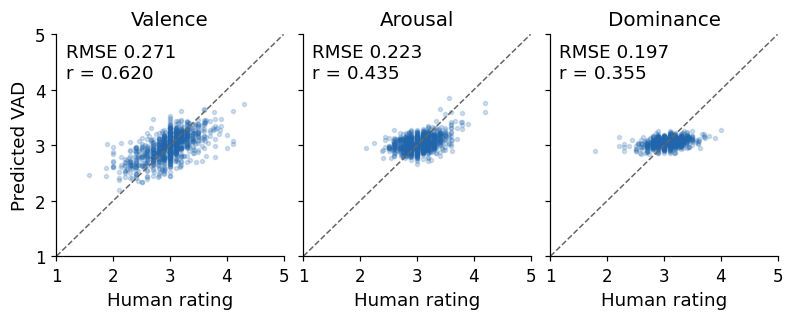

In [38]:
plot_gold = pd.read_csv(MODEL / 'heldout_predictions.csv')
plot_metrics = pd.read_csv(MODEL / 'test_metrics.csv').query("model == 'ridge'").set_index('dimension')
fig, axes = plt.subplots(1, 3, figsize=(7.1, 2.8), sharex=True, sharey=True, constrained_layout=True)
for ax, d in zip(axes, DIM_NAMES):
    ax.scatter(plot_gold[d], plot_gold[f'pred_{d}'], s=7, alpha=.20, color=BLUE, rasterized=True)
    ax.plot([1, 5], [1, 5], ls='--', lw=1, color=GREY)
    ax.set(xlim=(1, 5), ylim=(1, 5), xticks=[1, 2, 3, 4, 5], title=DIM_NAMES[d], xlabel='Human rating')
    ax.text(.04, .96, f"RMSE {plot_metrics.loc[d, 'rmse']:.3f}\nr = {plot_metrics.loc[d, 'pearson_r']:.3f}",
            transform=ax.transAxes, va='top', fontsize=12)
axes[0].set_ylabel('Predicted VAD')
display_figure(fig, 'source_evaluation')


**Figure 2 — VAD distributions.** Control vs. depression kernel density per
source (tweet, lyric) and dimension.


Figure: vad_distributions


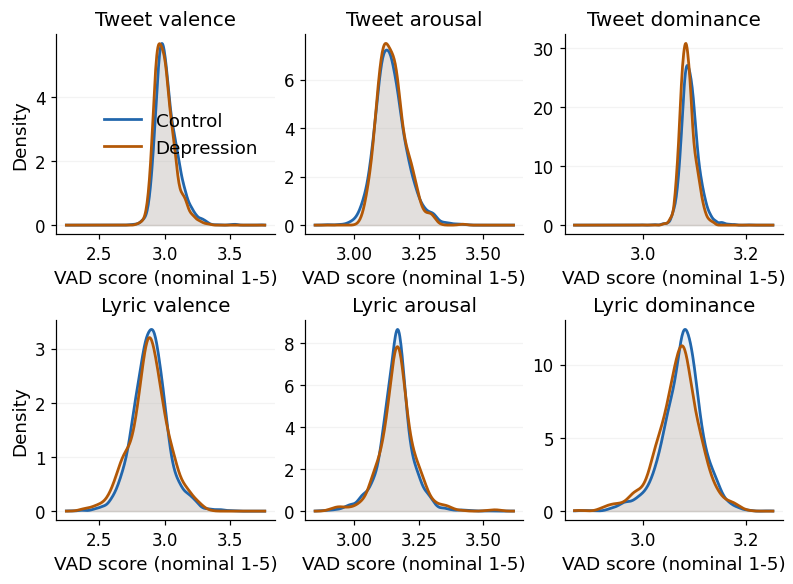

In [39]:
required_plot_inputs = ['participant_features.csv', 'group_tests_primary.csv', 'matching_correlations.csv']
missing_plot_inputs = [f for f in required_plot_inputs if not (OUT / f).exists()]
if missing_plot_inputs:
    raise FileNotFoundError(f'Run the main analysis section first; missing: {missing_plot_inputs}')

plot_df = pd.read_csv(OUT / 'participant_features.csv')
plot_effects = pd.read_csv(OUT / 'group_tests_primary.csv')
plot_corr = pd.read_csv(OUT / 'matching_correlations.csv')

fig, axes = plt.subplots(2, 3, figsize=(7.1, 5.2), constrained_layout=True)
for j, d in enumerate(DIM_NAMES):
    combined = np.r_[plot_df[f'tweet_{d}'], plot_df[f'lyric_{d}']]
    span = np.quantile(combined, .995) - np.quantile(combined, .005)
    grid = np.linspace(combined.min() - .04 * span, combined.max() + .04 * span, 350)
    for i, source in enumerate(['tweet', 'lyric']):
        ax = axes[i, j]
        for group, color, label in [('control', BLUE, 'Control'), ('depression', ORANGE, 'Depression')]:
            values = plot_df.loc[plot_df.disorder.eq(group), f'{source}_{d}']
            density = gaussian_kde(values)(grid)
            ax.plot(grid, density, color=color, lw=1.8, label=label)
            ax.fill_between(grid, density, color=color, alpha=.10)
        ax.set_title(f'{source.capitalize()} {DIM_NAMES[d].lower()}')
        ax.set_xlabel('VAD score (nominal 1-5)')
        ax.set_ylabel('Density' if j == 0 else '')
        ax.grid(axis='y', alpha=.15)
axes[0, 0].legend(frameon=False)
display_figure(fig, 'vad_distributions')


**Figure 3 — group effects.** Cliff's delta (depression minus control) for
all ten derived features, with participant bootstrap 95% intervals;
BH-significant features (q < 0.05) highlighted in orange.


Figure: group_effects


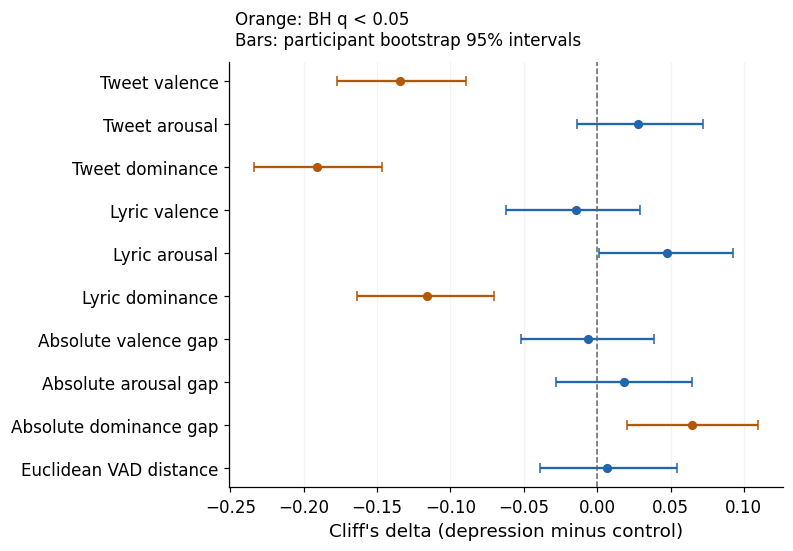

In [40]:
fig, ax = plt.subplots(figsize=(7.1, 4.9), constrained_layout=True)
positions = np.arange(len(plot_effects))[::-1]
for pos, row in zip(positions, plot_effects.itertuples()):
    color = ORANGE if row.q < .05 else BLUE
    ax.errorbar(row.delta, pos, xerr=[[row.delta - row.delta_ci_low], [row.delta_ci_high - row.delta]],
               fmt='o', color=color, capsize=3, markersize=5)
ax.axvline(0, color=GREY, ls='--', lw=1)
ax.set(yticks=positions, yticklabels=[FEATURE_NAMES[f] for f in plot_effects.feature],
       xlabel="Cliff's delta (depression minus control)")
ax.grid(axis='x', alpha=.15)
ax.text(.01, 1.03, 'Orange: BH q < 0.05\nBars: participant bootstrap 95% intervals',
        transform=ax.transAxes, ha='left', va='bottom', fontsize=11)
display_figure(fig, 'group_effects')


**Figure 4 — VAD alignment.** Scatter of mean tweet vs. mean lyric VAD per
participant, annotated with the overall Spearman rho and its 95% CI.


Figure: vad_alignment


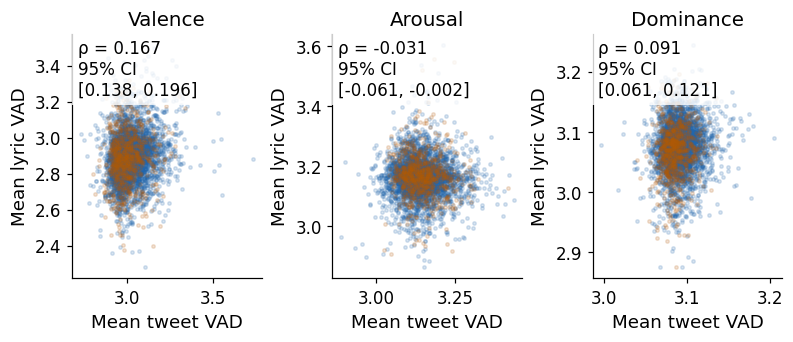

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(7.1, 3.0), constrained_layout=True)
for ax, d in zip(axes, DIM_NAMES):
    for group, color in [('control', BLUE), ('depression', ORANGE)]:
        sub = plot_df[plot_df.disorder.eq(group)]
        ax.scatter(sub[f'tweet_{d}'], sub[f'lyric_{d}'], s=5, alpha=.17, color=color, rasterized=True)
    row = plot_corr[(plot_corr.group == 'all') & (plot_corr.dimension == d)].iloc[0]
    ax.set(title=DIM_NAMES[d], xlabel='Mean tweet VAD', ylabel='Mean lyric VAD')
    ax.text(.03, .98, f"ρ = {row.rho:.3f}\n95% CI\n[{row.ci_low:.3f}, {row.ci_high:.3f}]",
            transform=ax.transAxes, va='top', fontsize=11, bbox={'facecolor': 'white', 'alpha': .8, 'edgecolor': 'none'})
display_figure(fig, 'vad_alignment')


**Figure 5 — classification ablation and sensitivity.** Pooled OOF AUROC
with bootstrap intervals, first across feature-set ablations (tweets,
lyrics, combined, combined+derived), then across sample-selection
sensitivity variants.


Figure: classification_ablation


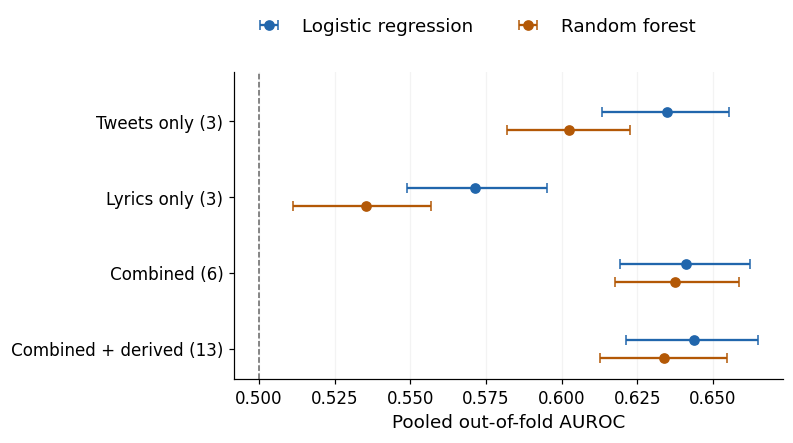

Figure: classification_sensitivity


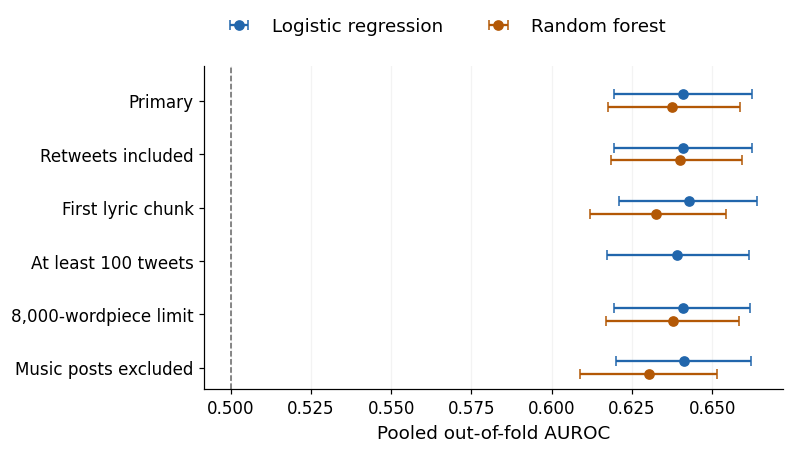

Figures complete


In [42]:
if not (OUT / 'classification_summary.csv').exists():
    raise FileNotFoundError('Run the main analysis section first; missing classification_summary.csv')
plot_summary = pd.read_csv(OUT / 'classification_summary.csv')
feature_labels = {'tweets': 'Tweets only (3)', 'lyrics': 'Lyrics only (3)', 'combined': 'Combined (6)', 'derived': 'Combined + derived (13)'}

fig, ax = plt.subplots(figsize=(7.1, 3.9), constrained_layout=True)
for model, offset, color in [('LR', .12, BLUE), ('RF', -.12, ORANGE)]:
    for j, f in enumerate(feature_labels):
        row = plot_summary[(plot_summary.variant == 'primary') & (plot_summary.features == f) & (plot_summary.model == model)].iloc[0]
        ax.errorbar(row.pooled_oof_auroc, 3 - j + offset,
                   xerr=[[row.pooled_oof_auroc - row.oof_auroc_ci_low], [row.oof_auroc_ci_high - row.pooled_oof_auroc]],
                   fmt='o', color=color, capsize=3,
                   label=('Logistic regression' if model == 'LR' else 'Random forest') if j == 0 else None)
ax.axvline(.5, ls='--', color=GREY, lw=1)
ax.set(yticks=np.arange(4)[::-1], yticklabels=list(feature_labels.values()), xlabel='Pooled out-of-fold AUROC', ylim=(-.4, 3.65))
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0, 1.23), ncol=2)
ax.grid(axis='x', alpha=.15)
display_figure(fig, 'classification_ablation')

sensitivity_labels = {'primary': 'Primary', 'retweets_included': 'Retweets included', 'lyric_prefix': 'First lyric chunk',
                      'at_least_100_tweets': 'At least 100 tweets', 'lyric_8000_limit': '8,000-wordpiece limit',
                      'music_posts_excluded': 'Music posts excluded'}
fig, ax = plt.subplots(figsize=(7.1, 4.0), constrained_layout=True)
for model, offset, color in [('LR', .12, BLUE), ('RF', -.12, ORANGE)]:
    for j, variant in enumerate(sensitivity_labels):
        sub = plot_summary[(plot_summary.variant == variant) & (plot_summary.features == 'combined') & (plot_summary.model == model)]
        if sub.empty:
            continue
        row = sub.iloc[0]
        ax.errorbar(row.pooled_oof_auroc, 5 - j + offset,
                   xerr=[[row.pooled_oof_auroc - row.oof_auroc_ci_low], [row.oof_auroc_ci_high - row.pooled_oof_auroc]],
                   fmt='o', color=color, capsize=3,
                   label=('Logistic regression' if model == 'LR' else 'Random forest') if j == 0 else None)
ax.axvline(.5, ls='--', color=GREY, lw=1)
ax.set(yticks=np.arange(6)[::-1], yticklabels=list(sensitivity_labels.values()), xlabel='Pooled out-of-fold AUROC', ylim=(-.4, 5.65))
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0, 1.2), ncol=2)
ax.grid(axis='x', alpha=.15)
display_figure(fig, 'classification_sensitivity')
print('Figures complete', flush=True)


## 14. Manuscript tables

Builds the same numerical content as the original LaTeX table fragments
(group tests, matching correlations, classification summary, paired
ablation, and the sensitivity variants)


In [43]:
table_features = {'tweet_V': 'Tweet valence', 'tweet_A': 'Tweet arousal', 'tweet_D': 'Tweet dominance',
                  'lyric_V': 'Lyric valence', 'lyric_A': 'Lyric arousal', 'lyric_D': 'Lyric dominance',
                  'gap_V': 'Absolute valence gap', 'gap_A': 'Absolute arousal gap', 'gap_D': 'Absolute dominance gap',
                  'distance': 'Euclidean VAD distance'}

def format_pvalue(x):
    if x >= .0001:
        return f'{x:.4f}'
    mantissa, exponent = f'{x:.2e}'.split('e')
    return f'{mantissa}e{int(exponent)}'

group_tests_df = pd.read_csv(OUT / 'group_tests_primary.csv')
group_tests_table = pd.DataFrame([
    {'Feature': table_features[r.feature], "Cliff's delta": f'{r.delta:.3f}',
     '95% CI': f'[{r.delta_ci_low:.3f}, {r.delta_ci_high:.3f}]',
     'p': format_pvalue(r.p), 'q (BH)': format_pvalue(r.q)}
    for r in group_tests_df.itertuples()])
print('Group tests (primary):')
display(group_tests_table)

matching_df = pd.read_csv(OUT / 'matching_correlations.csv')
matching_rows = []
for group in ['all', 'control', 'depression']:
    for d, label in [('V', 'Valence'), ('A', 'Arousal'), ('D', 'Dominance')]:
        r = matching_df[(matching_df.group == group) & (matching_df.dimension == d)].iloc[0]
        matching_rows.append({'Group': group.capitalize(), 'Dimension': label,
                              'rho': f'{r.rho:.3f}', '95% CI': f'[{r.ci_low:.3f}, {r.ci_high:.3f}]'})
matching_table = pd.DataFrame(matching_rows)
print('Matching correlations:')
display(matching_table)

if not (OUT / 'classification_summary.csv').exists():
    raise FileNotFoundError('Run the main analysis section first; missing classification_summary.csv')
classification_df = pd.read_csv(OUT / 'classification_summary.csv')
classification_labels = {'tweets': 'Tweets (3)', 'lyrics': 'Lyrics (3)', 'combined': 'Combined (6)', 'derived': 'Combined + derived (13)'}
classification_rows = []
for f, label in classification_labels.items():
    for model in ['LR', 'RF']:
        r = classification_df[(classification_df.variant == 'primary') & (classification_df.features == f) & (classification_df.model == model)].iloc[0]
        classification_rows.append({'Features': label, 'Model': model,
                                    'Mean AUROC': f'{r.fold_mean_auroc:.3f} \u00b1 {r.fold_sd_auroc:.3f}',
                                    'Mean balanced accuracy': f'{r.fold_mean_balanced_accuracy:.3f} \u00b1 {r.fold_sd_balanced_accuracy:.3f}'})
classification_table = pd.DataFrame(classification_rows)
print('Classification summary (primary variant):')
display(classification_table)

if not (OUT / 'paired_ablation_differences.csv').exists():
    raise FileNotFoundError('Run the main analysis section first; missing paired_ablation_differences.csv')
paired_df = pd.read_csv(OUT / 'paired_ablation_differences.csv')
paired_table = pd.DataFrame([
    {'Model': r.model, 'Comparison': f"Combined minus {r.comparison.removeprefix('combined_minus_')}",
     'AUROC difference': f'{r.pooled_auc_difference:.3f}', '95% CI': f'[{r.ci_low:.3f}, {r.ci_high:.3f}]'}
    for r in paired_df.itertuples()])
print('Paired ablation differences:')
display(paired_table)

sensitivity_labels = {'primary': 'Primary', 'retweets_included': 'Retweets included', 'lyric_prefix': 'First lyric chunk',
                      'at_least_100_tweets': 'At least 100 tweets', 'lyric_8000_limit': '8,000-wordpiece limit',
                      'music_posts_excluded': 'Music posts excluded'}
sensitivity_rows = []
for variant, label in sensitivity_labels.items():
    sub = classification_df[(classification_df.variant == variant) & (classification_df.features == 'combined')]
    n = int(sub.iloc[0].n)
    row = {'Variant': label, 'N': f'{n:,}'}
    for model in ['LR', 'RF']:
        selected = sub[sub.model == model]
        row[model] = '—' if selected.empty else f'{selected.iloc[0].fold_mean_auroc:.3f} \u00b1 {selected.iloc[0].fold_sd_auroc:.3f}'
    sensitivity_rows.append(row)
sensitivity_table = pd.DataFrame(sensitivity_rows)
print('Sensitivity (combined features, fold-mean AUROC):')
display(sensitivity_table)

print('Manuscript tables displayed', flush=True)


Group tests (primary):


,Feature,Cliff's delta,95% CI,p,q (BH)
0,Tweet valence,-0.134,"[-0.178, -0.090]",7.16e-9,3.58e-8
1,Tweet arousal,0.028,"[-0.014, 0.072]",0.2258,0.3763
2,Tweet dominance,-0.191,"[-0.234, -0.147]",1.70e-16,1.70e-15
3,Lyric valence,-0.015,"[-0.062, 0.029]",0.5257,0.6571
4,Lyric arousal,0.048,"[0.001, 0.092]",0.0405,0.0809
5,Lyric dominance,-0.116,"[-0.164, -0.070]",5.64e-7,1.88e-6
6,Absolute valence gap,-0.007,"[-0.052, 0.038]",0.7781,0.7781
7,Absolute arousal gap,0.019,"[-0.028, 0.065]",0.4238,0.6054
8,Absolute dominance gap,0.065,"[0.021, 0.109]",0.0051,0.0127
9,Euclidean VAD distance,0.007,"[-0.039, 0.054]",0.7661,0.7781


Matching correlations:


,Group,Dimension,rho,95% CI
0,All,Valence,0.167,"[0.138, 0.196]"
1,All,Arousal,-0.031,"[-0.061, -0.002]"
2,All,Dominance,0.091,"[0.061, 0.121]"
3,Control,Valence,0.179,"[0.146, 0.211]"
4,Control,Arousal,-0.020,"[-0.053, 0.013]"
5,Control,Dominance,0.076,"[0.043, 0.110]"
6,Depression,Valence,0.113,"[0.040, 0.185]"
7,Depression,Arousal,-0.085,"[-0.152, -0.014]"
8,Depression,Dominance,0.108,"[0.036, 0.178]"


Classification summary (primary variant):


...

Paired ablation differences:


,Model,Comparison,AUROC difference,95% CI
0,LR,Combined minus tweets,0.006,"[-0.003, 0.015]"
1,LR,Combined minus lyrics,0.070,"[0.047, 0.092]"
2,RF,Combined minus tweets,0.035,"[0.016, 0.055]"
3,RF,Combined minus lyrics,0.102,"[0.077, 0.127]"


Sensitivity (combined features, fold-mean AUROC):


,Variant,N,LR,RF
0,Primary,"4,256",0.641 ± 0.021,0.638 ± 0.014
1,Retweets included,"4,256",0.641 ± 0.021,0.640 ± 0.012
2,First lyric chunk,"4,256",0.643 ± 0.020,0.633 ± 0.018
3,At least 100 tweets,"3,851",0.640 ± 0.037,—
4,"8,000-wordpiece limit","4,256",0.641 ± 0.021,0.638 ± 0.015
5,Music posts excluded,"4,255",0.642 ± 0.017,0.630 ± 0.010


Manuscript tables displayed
